# Validating `SmoothTrend` against pytrale's existing algorithms

`pytrale.algorithms.SmoothTrend` models the latent body weight as a
once-integrated Wiener process — Harvey's local linear trend with the level
disturbance set to zero — and infers it with a Kalman filter followed by an
RTS smoother. That is the exact Gaussian-process posterior in `O(N)`.

This notebook exists to answer one question first and everything else
afterwards:

> *"Using BFGS might be easy with scipy, but I am afraid that there is no
> implementation available in dart."*

Section 0 shows that no gradient-based optimizer is needed at all. The
remaining sections measure the algorithm against the three already in the
repository, and report the places where it does **not** win.

Everything below runs on NumPy only, except one explicitly labelled
cross-check in §0. Nothing in `src/` was changed to produce these results.


In [28]:
import contextlib
import io
import pathlib
import sys
import time

import numpy as np
import prettypyplot as pplt
from matplotlib import pyplot as plt

from pytrale import Trale
from pytrale.algorithms import (
    GaussianKernelSmoother,
    GaussianProcess,
    LinearInterpolator,
    SmoothTrend,
)
from pytrale.algorithms.base import Interpolator
from pytrale.algorithms.smooth_trend import _concentrated_objective

# The trale preview series lives with the tests, which are not installed.
sys.path.insert(0, "..")
from tests.preview_data import preview_measurements  # noqa: E402

pplt.use_style(figsize=(8, 3), latex=False)
np.set_printoptions(precision=3, suppress=True)

## The data

Three sources, in decreasing order of how much they should be believed:

1. **`preview`** — the 60-day series trale ships for its UI previews, with
   the time axis flipped (the Dart source indexes *backwards* from today) and
   its six deliberate gaps. Synthetic, short, and the only series both
   projects already share, so it is the honest "apples to apples" figure.
2. **`synthetic_2y` / `synthetic_1y`** — drawn from a generative model that
   is deliberately *not* the one `SmoothTrend` assumes: it adds a weekly
   cycle and gross outliers on top of the integrated Wiener process. Long
   enough to estimate hyperparameters and to see the weekly component.
3. **Real exports**, if any `*.txt` is dropped into `notebooks/data/`.

Point 2 is the weak link and it should be said plainly: a synthetic series
whose trend component comes from `SmoothTrend`'s own prior flatters
`SmoothTrend`. The weekly cycle and the outliers are there precisely to stop
it being a rigged demo — both are model misspecification the algorithm has
to absorb. **Real multi-year exports would replace this entirely**, and are
worth asking for before the PR is judged on these numbers.


In [29]:
def synthetic_history(
    n_days=730,
    seed=0,
    weekly_amplitude=0.25,
    diffusion=1.5e-4,
    sigma_eps=0.75,
    sampling_rate=4 / 7,
    outlier_rate=0.02,
    outlier_size=2.0,
):
    """Draw a weight history with a weekly cycle and gross outliers."""
    rng = np.random.default_rng(seed)
    increment_cov = diffusion * np.array([[1 / 3, 1 / 2], [1 / 2, 1.0]])

    level, rate = 82.0, -0.004
    levels = np.empty(n_days)
    for day in range(n_days):
        step_level, step_rate = rng.multivariate_normal([0.0, 0.0], increment_cov)
        level, rate = level + rate + step_level, rate + step_rate
        levels[day] = level

    days = np.arange(n_days, dtype=float)
    weekly = weekly_amplitude * np.cos(2 * np.pi * (days % 7) / 7)

    observed = rng.random(n_days) < sampling_rate
    times = days[observed]
    weights = (levels + weekly)[observed] + rng.normal(0.0, sigma_eps, observed.sum())
    is_outlier = rng.random(times.size) < outlier_rate
    weights = weights + is_outlier * rng.choice([-1.0, 1.0], times.size) * outlier_size
    return times, weights, levels


SERIES = {"preview": preview_measurements()}
SERIES["synthetic_1y"] = synthetic_history(n_days=365, seed=1)[:2]
SERIES["synthetic_2y"] = synthetic_history(n_days=730, seed=2)[:2]

# Any real export dropped into notebooks/data/ is picked up automatically.
for path in sorted(pathlib.Path("data").glob("*.txt")):
    db = Trale.fromFile(str(path))
    SERIES[path.stem] = (db.times_measured, db.weights_measured)

for name, (times, weights) in SERIES.items():
    span = times.max() - times.min()
    print(
        f"{name:>14}: {times.size:4d} measurements over {span:6.0f} days "
        f"({times.size / span * 7:.1f} per week), "
        f"{weights.min():.1f}-{weights.max():.1f} kg"
    )


       preview:   54 measurements over     59 days (6.4 per week), 79.5-82.8 kg
  synthetic_1y:  199 measurements over    361 days (3.9 per week), 80.2-160.5 kg
  synthetic_2y:  437 measurements over    729 days (4.2 per week), 39.7-83.0 kg


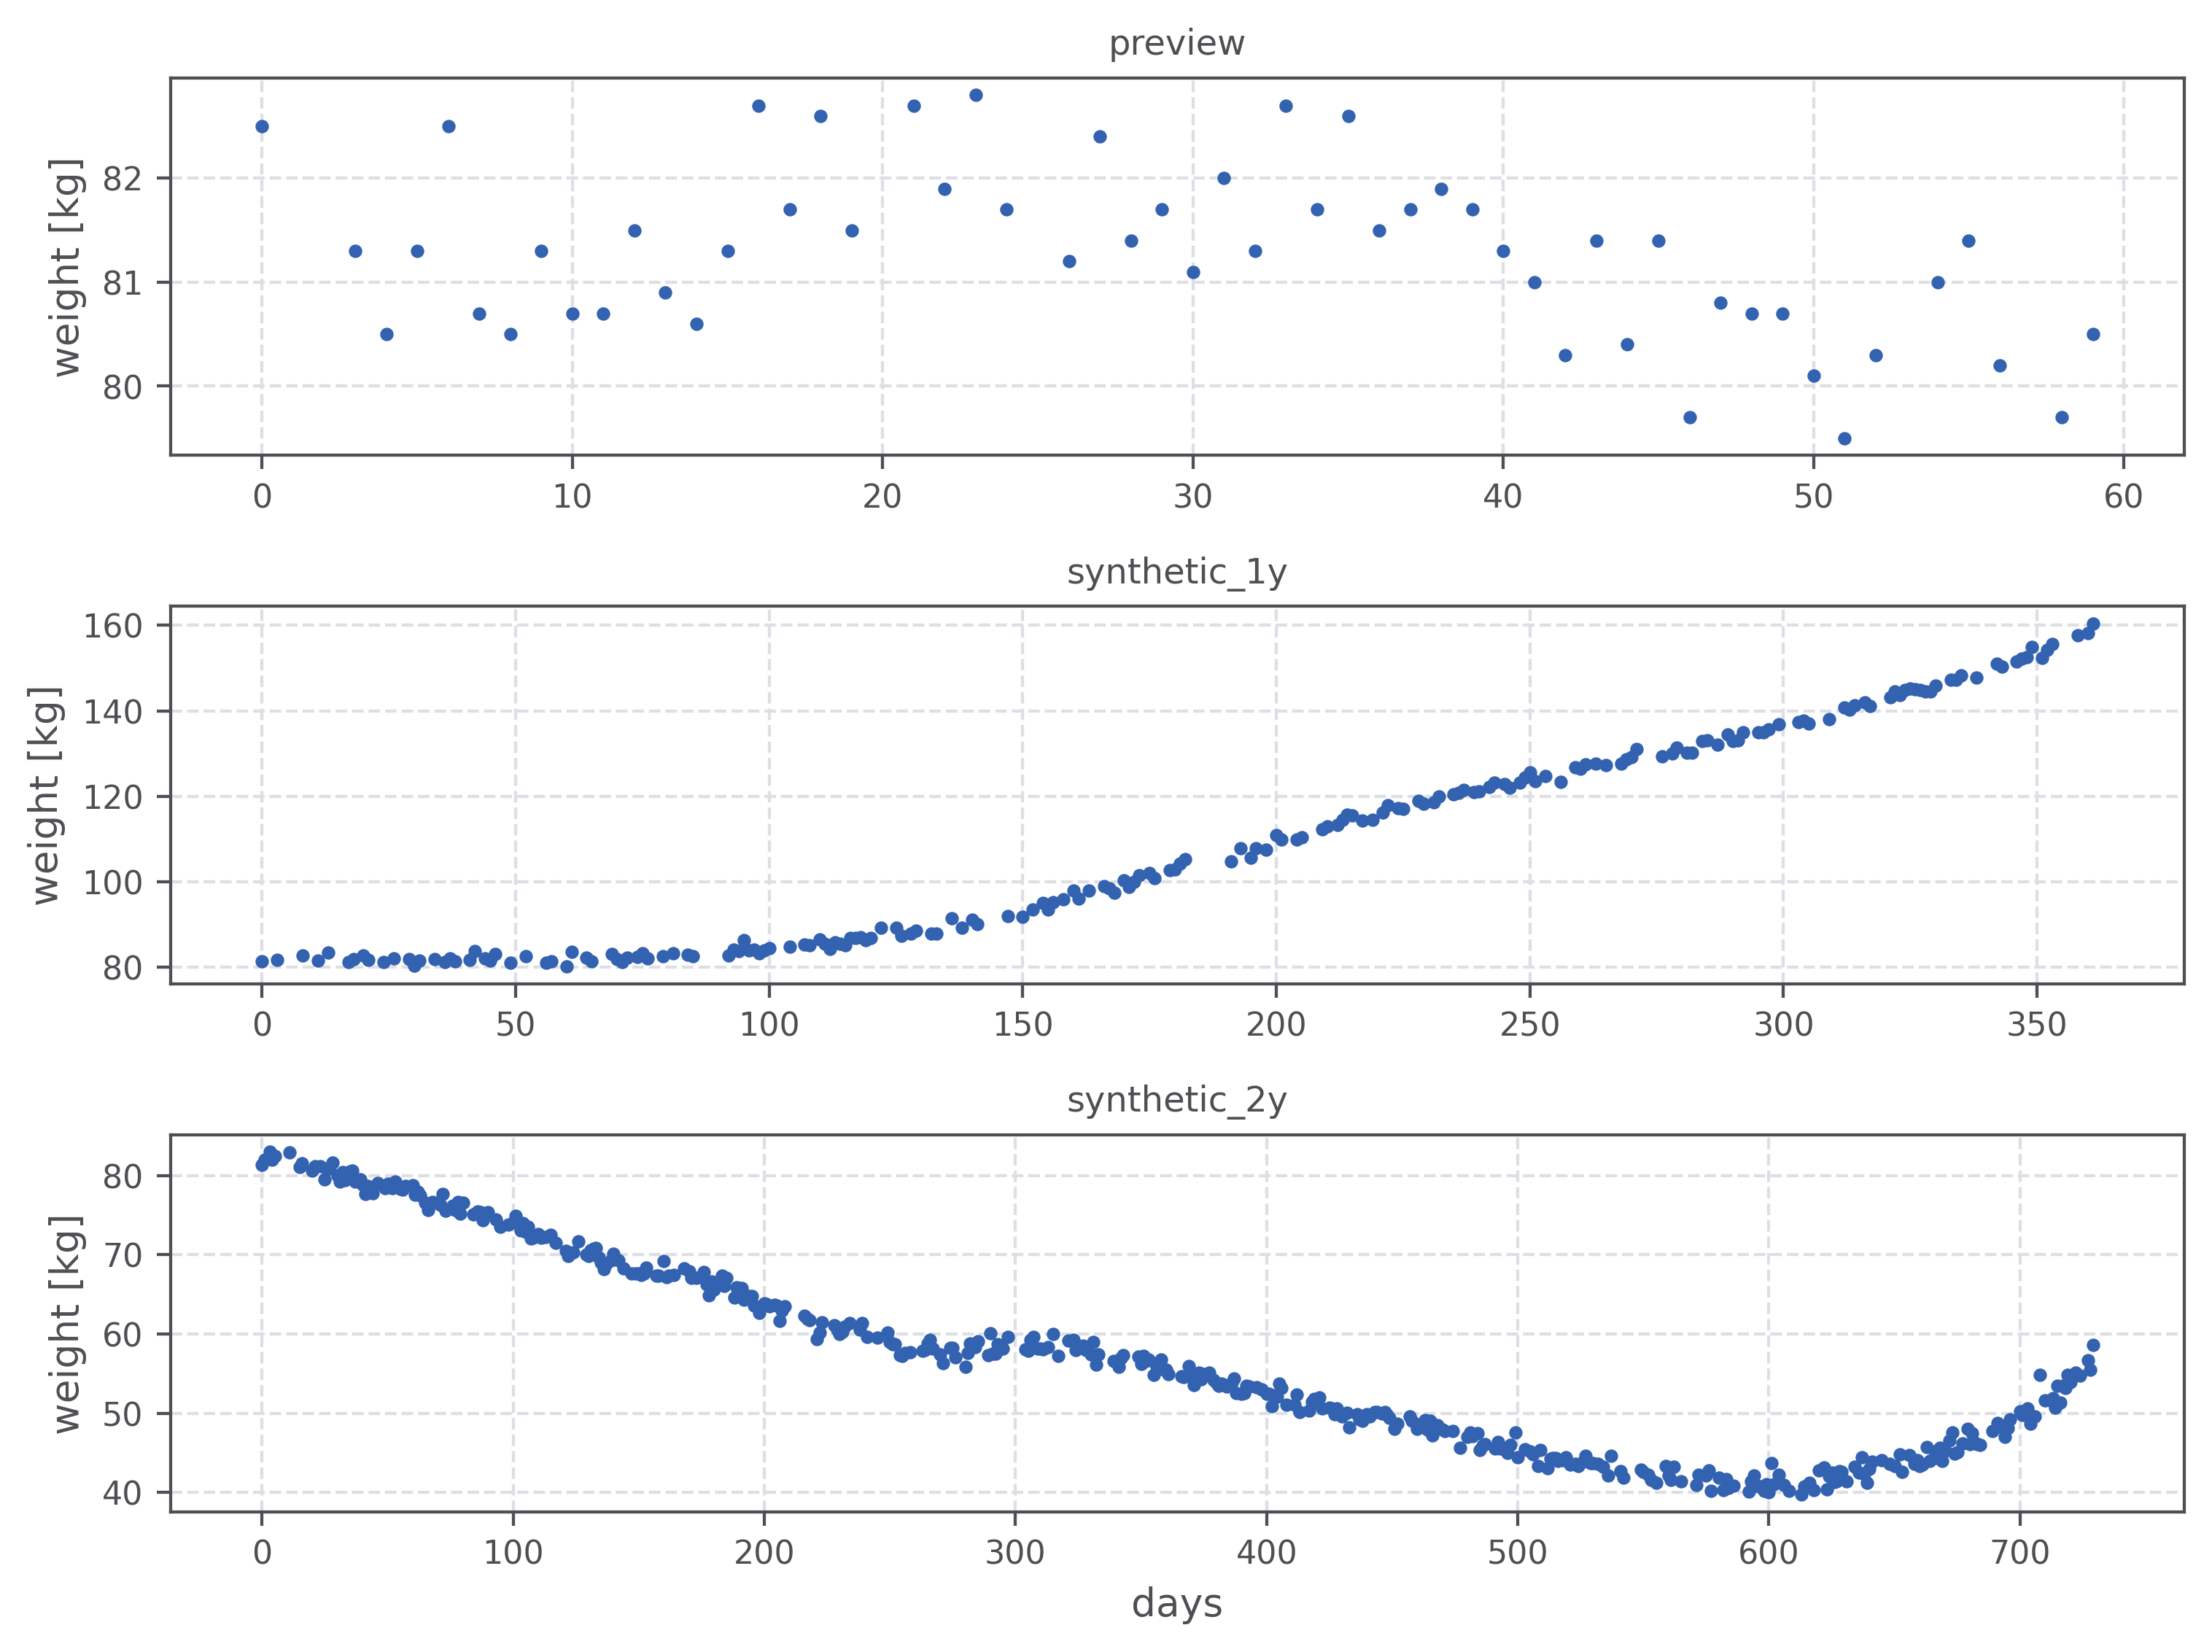

In [30]:
fig, axes = plt.subplots(len(SERIES), 1, figsize=(8, 2 * len(SERIES)))
axes = np.atleast_1d(axes)
for ax, (name, (times, weights)) in zip(axes, SERIES.items(), strict=True):
    ax.scatter(times - times.min(), weights, s=6)
    ax.set_ylabel("weight [kg]")
    ax.set_title(name, fontsize=9)
axes[-1].set_xlabel("days")
plt.tight_layout()
plt.show()

---

# §0 — There is no optimizer to port

The hyperparameters of the smooth-trend model are the diffusion `q` and the
observation noise `sigma_eps`. Two reductions collapse that to a single
scalar search:

1. **`sigma_xi = 0`.** Dropping the level disturbance removes a third
   hyperparameter that is only weakly identified against `q` anyway
   (Harvey 1989, §5.4).
2. **Concentrating the scale.** Writing `R = sigma_eps^2` and
   `Q = sigma_eps^2 * lam * Q0(dt)`, every covariance in the recursion carries
   a factor `sigma_eps^2`, so the Kalman gains — and therefore the state
   estimates — do not depend on it. Differentiating the likelihood gives
   `sigma_eps^2` in closed form, and what is left is

   ```
   l_c(lam) = m * log( sum_t delta_t^2 / S_t ) + sum_t log S_t
   ```

   with `delta` and `S` already produced by the forward pass.

`lam` has units of day^-3 and relates to the equivalent kernel bandwidth `h`
of Silverman (1984) as `lam = h^-4` exactly, with `sigma_eps` cancelling.
So the search range is chosen in days, not in abstract units.


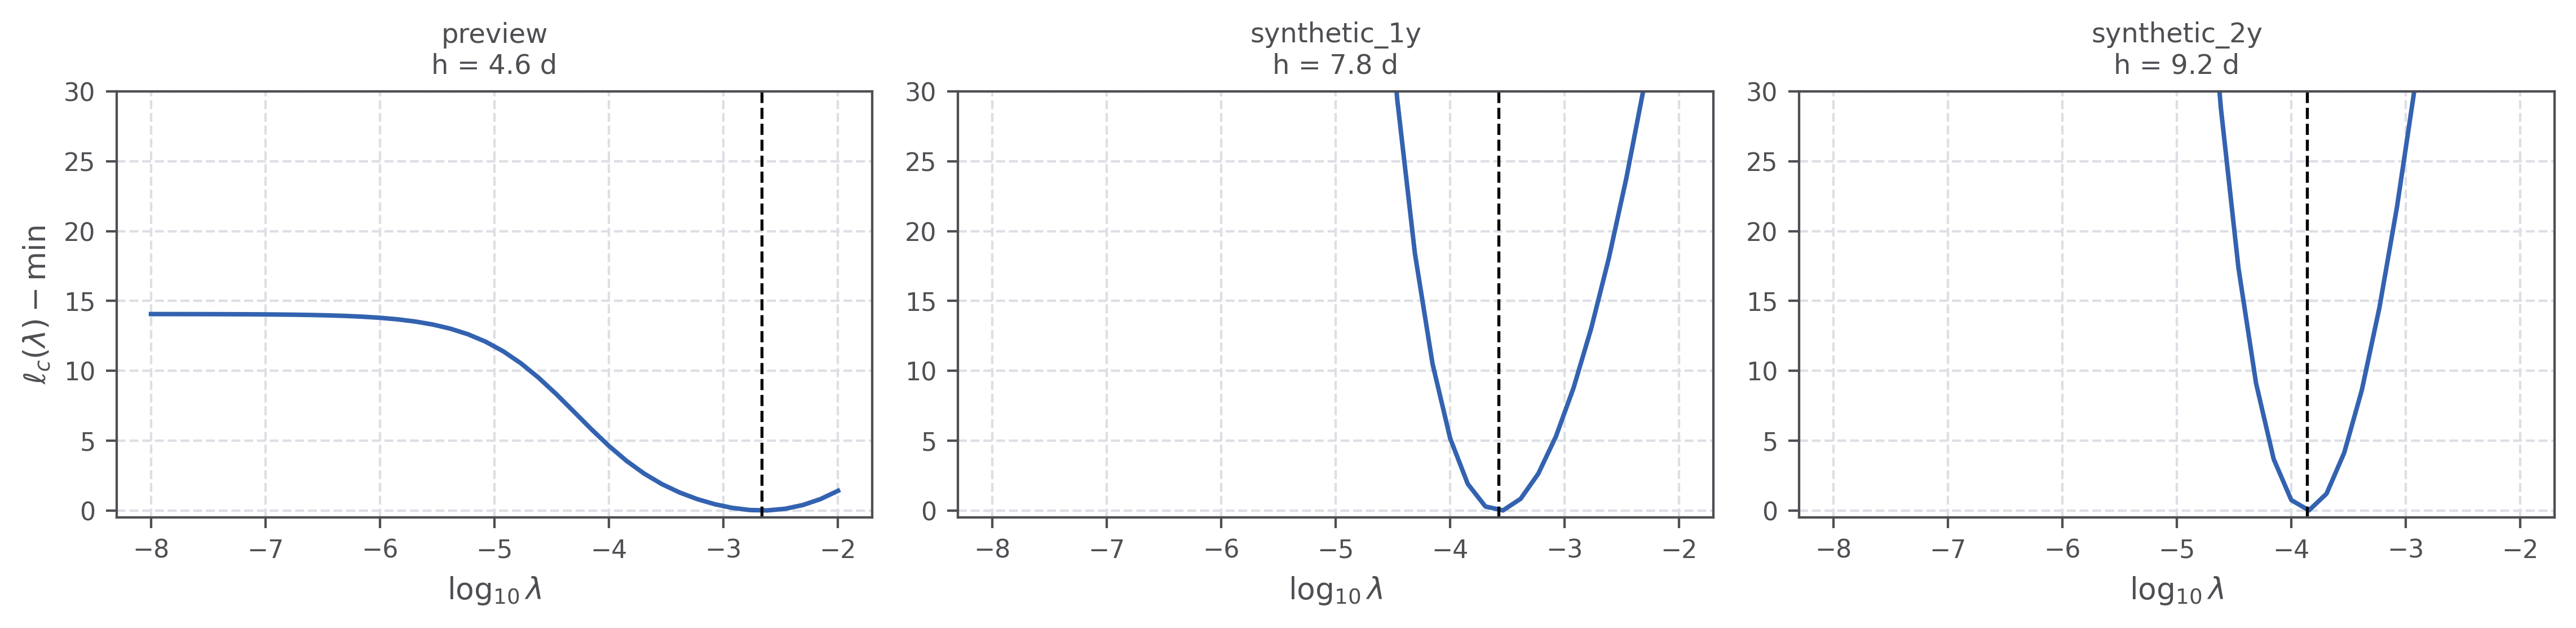

In [31]:
GRID = np.linspace(-8.0, -2.0, 40)

fig, axes = plt.subplots(1, len(SERIES), figsize=(4 * len(SERIES), 3))
axes = np.atleast_1d(axes)
for ax, (name, (times, weights)) in zip(axes, SERIES.items(), strict=True):
    order = np.argsort(times)
    t, w = times[order] - times[order][0], weights[order]
    objective = np.array([_concentrated_objective(x, t, w, 0.035) for x in GRID])

    model = SmoothTrend().fit(times, weights)
    ax.plot(GRID, objective - objective.min())
    ax.axvline(np.log10(model.lam_), color="k", ls="--", lw=1)
    ax.set_title(f"{name}\nh = {model.bandwidth_:.1f} d", fontsize=9)
    ax.set_xlabel(r"$\log_{10}\lambda$")
    ax.set_ylim(-0.5, 30)
axes[0].set_ylabel(r"$\ell_c(\lambda) - \min$")
plt.tight_layout()
plt.show()


The objective is smooth and has a single interior minimum. That is all a
fixed grid plus one parabolic refinement needs — no gradients, no line
search, no convergence tolerance, and a bit-for-bit reproducible answer.

The cell below is the **only** use of SciPy in this notebook, and it exists
solely to show that a real optimizer lands in the same place. It is not on
the code path and has no counterpart in `src/`.


In [32]:
from scipy.optimize import minimize_scalar  # cross-check only, not used by pytrale

print(f"{'series':>14}  {'grid + parabola':>16}  {'Brent (scipy)':>14}  {'diff':>8}")
for name, (times, weights) in SERIES.items():
    order = np.argsort(times)
    t, w = times[order] - times[order][0], weights[order]

    grid_lam = SmoothTrend().fit(times, weights).lam_
    brent = minimize_scalar(
        _concentrated_objective, bounds=(-8.0, -2.0), method="bounded",
        args=(t, w, 0.035), options={"xatol": 1e-8},
    )
    brent_lam = 10.0**brent.x
    print(
        f"{name:>14}  {grid_lam:16.3e}  {brent_lam:14.3e}  "
        f"{abs(grid_lam / brent_lam - 1) * 100:7.2f}%"
    )


        series   grid + parabola   Brent (scipy)      diff
       preview         2.165e-03       2.174e-03     0.39%
  synthetic_1y         2.650e-04       2.629e-04     0.81%
  synthetic_2y         1.367e-04       1.358e-04     0.68%


The grid agrees with Brent's method to well under a percent on `lam`, which
is far below the resolution at which the resulting curve changes visibly
(`lam` enters the bandwidth as a fourth root, so a 1 % error in `lam` is a
0.25 % error in `h`).

Transcribed to Dart, the whole hyperparameter fit is this — no packages:

```dart
double fitLambda(List<double> t, List<double> y) {
  const int nGrid = 40;
  const double lo = -8.0, hi = -2.0;
  final double step = (hi - lo) / (nGrid - 1);
  final List<double> obj = List<double>.filled(nGrid, 0.0);

  for (int i = 0; i < nGrid; i++) {
    obj[i] = concentratedObjective(lo + i * step, t, y);
  }

  int best = 0;
  for (int i = 1; i < nGrid; i++) {
    if (obj[i] < obj[best]) best = i;
  }

  double x = lo + best * step;
  if (best > 0 && best < nGrid - 1) {
    final double c = obj[best - 1] - 2 * obj[best] + obj[best + 1];
    if (c > 0) x += 0.5 * step * (obj[best - 1] - obj[best + 1]) / c;
  }
  return math.pow(10.0, x).toDouble();
}
```


---

# §1 — The four algorithms on the shared series

The `preview` series is the one both repositories already have. Only two of
the four algorithms can draw a credibility band; that asymmetry is the point
of the figure as much as the curves are.


In [33]:
class TunedGaussianProcess(Interpolator):
    """The repo's `GaussianProcess`, wrapped so it can be compared fairly.

    As shipped it cannot be pointed at a trale export: its prior mean is
    zero while weights are ~80 kg, its length scales default to 1.0 while
    export times are ~2e4 (days since the epoch), and `fit` does not tune
    anything. This wrapper centres the data, shifts the origin, seeds the
    kernel from the data's own scales, runs the included optimizer and keeps
    whichever of the two has the higher marginal likelihood. That is the
    most favourable reading of the algorithm, not a hobbled one.
    """

    def __init__(self, n_iters=60, n_restarts=1, seed=0, frozen=None):
        self.n_iters, self.n_restarts, self.seed = n_iters, n_restarts, seed
        self.frozen = frozen

    @staticmethod
    def _scale_aware(x, y):
        # From the library defaults (every length scale 1.0, unit signal
        # variance) the optimizer collapses on long series: it drives the
        # trend length scale to zero and lets the noise absorb everything.
        # Seeding it from the data's own scales is the fair reading.
        noise = 0.5 * np.var(np.diff(y)) if y.size > 1 else 1.0
        return GaussianProcess(
            trend_length_scale=max(10.0, (x.max() - x.min()) / 10.0),
            trend_signal_variance=max(np.var(y), 1e-3),
            weekly_length_scale=1.0, weekly_signal_variance=0.05,
            monthly_length_scale=1.0, monthly_signal_variance=0.05,
            annual_length_scale=1.0, annual_signal_variance=0.05,
            noise_variance=max(noise, 1e-3),
        )

    def fit(self, times_measured, weights_measured):
        self._t0 = float(np.min(times_measured))
        self._mean = float(np.mean(weights_measured))
        x = np.asarray(times_measured, float) - self._t0
        y = np.asarray(weights_measured, float) - self._mean

        if self.frozen is not None:
            self._gp = self.frozen
            self._gp.fit(x, y)
            return self

        np.random.seed(self.seed)
        self._gp = self._scale_aware(x, y)
        self._gp.fit(x, y)
        start_params = self._gp.get_log_params()
        start_lml = self._gp.log_marginal_likelihood(x, y)

        with contextlib.redirect_stderr(io.StringIO()):
            self._gp.optimize_hyperparameters_log(
                x, y, n_iters=self.n_iters, n_restarts=self.n_restarts
            )
        self._gp.fit(x, y)
        # Never report a fit the optimizer left worse than where it started.
        if self._gp.log_marginal_likelihood(x, y) < start_lml:
            self._gp.set_params_from_log(start_params)
            self._gp.fit(x, y)
        return self

    def predict(self, times):
        return self._gp.predict(np.asarray(times, float) - self._t0) + self._mean

    def predict_std(self, times):
        _, var = self._gp.predict_with_uncertainty(
            np.asarray(times, float) - self._t0
        )
        return np.sqrt(np.maximum(var, 0.0))

    @property
    def noise_variance_(self):
        return self._gp.noise_variance


GP_CACHE = {}


def tuned_gp(name, times, weights):
    """Tune the GP once per series and reuse it everywhere.

    60 iterations lands within 0.5 % of the marginal likelihood reached by
    150, at a twentieth of the cost (30 s versus 9 minutes on two years of
    data). The `O(N^3)` fit is why this caching is needed at all.
    """
    if name not in GP_CACHE:
        GP_CACHE[name] = TunedGaussianProcess(n_iters=60).fit(times, weights)
    return GP_CACHE[name]


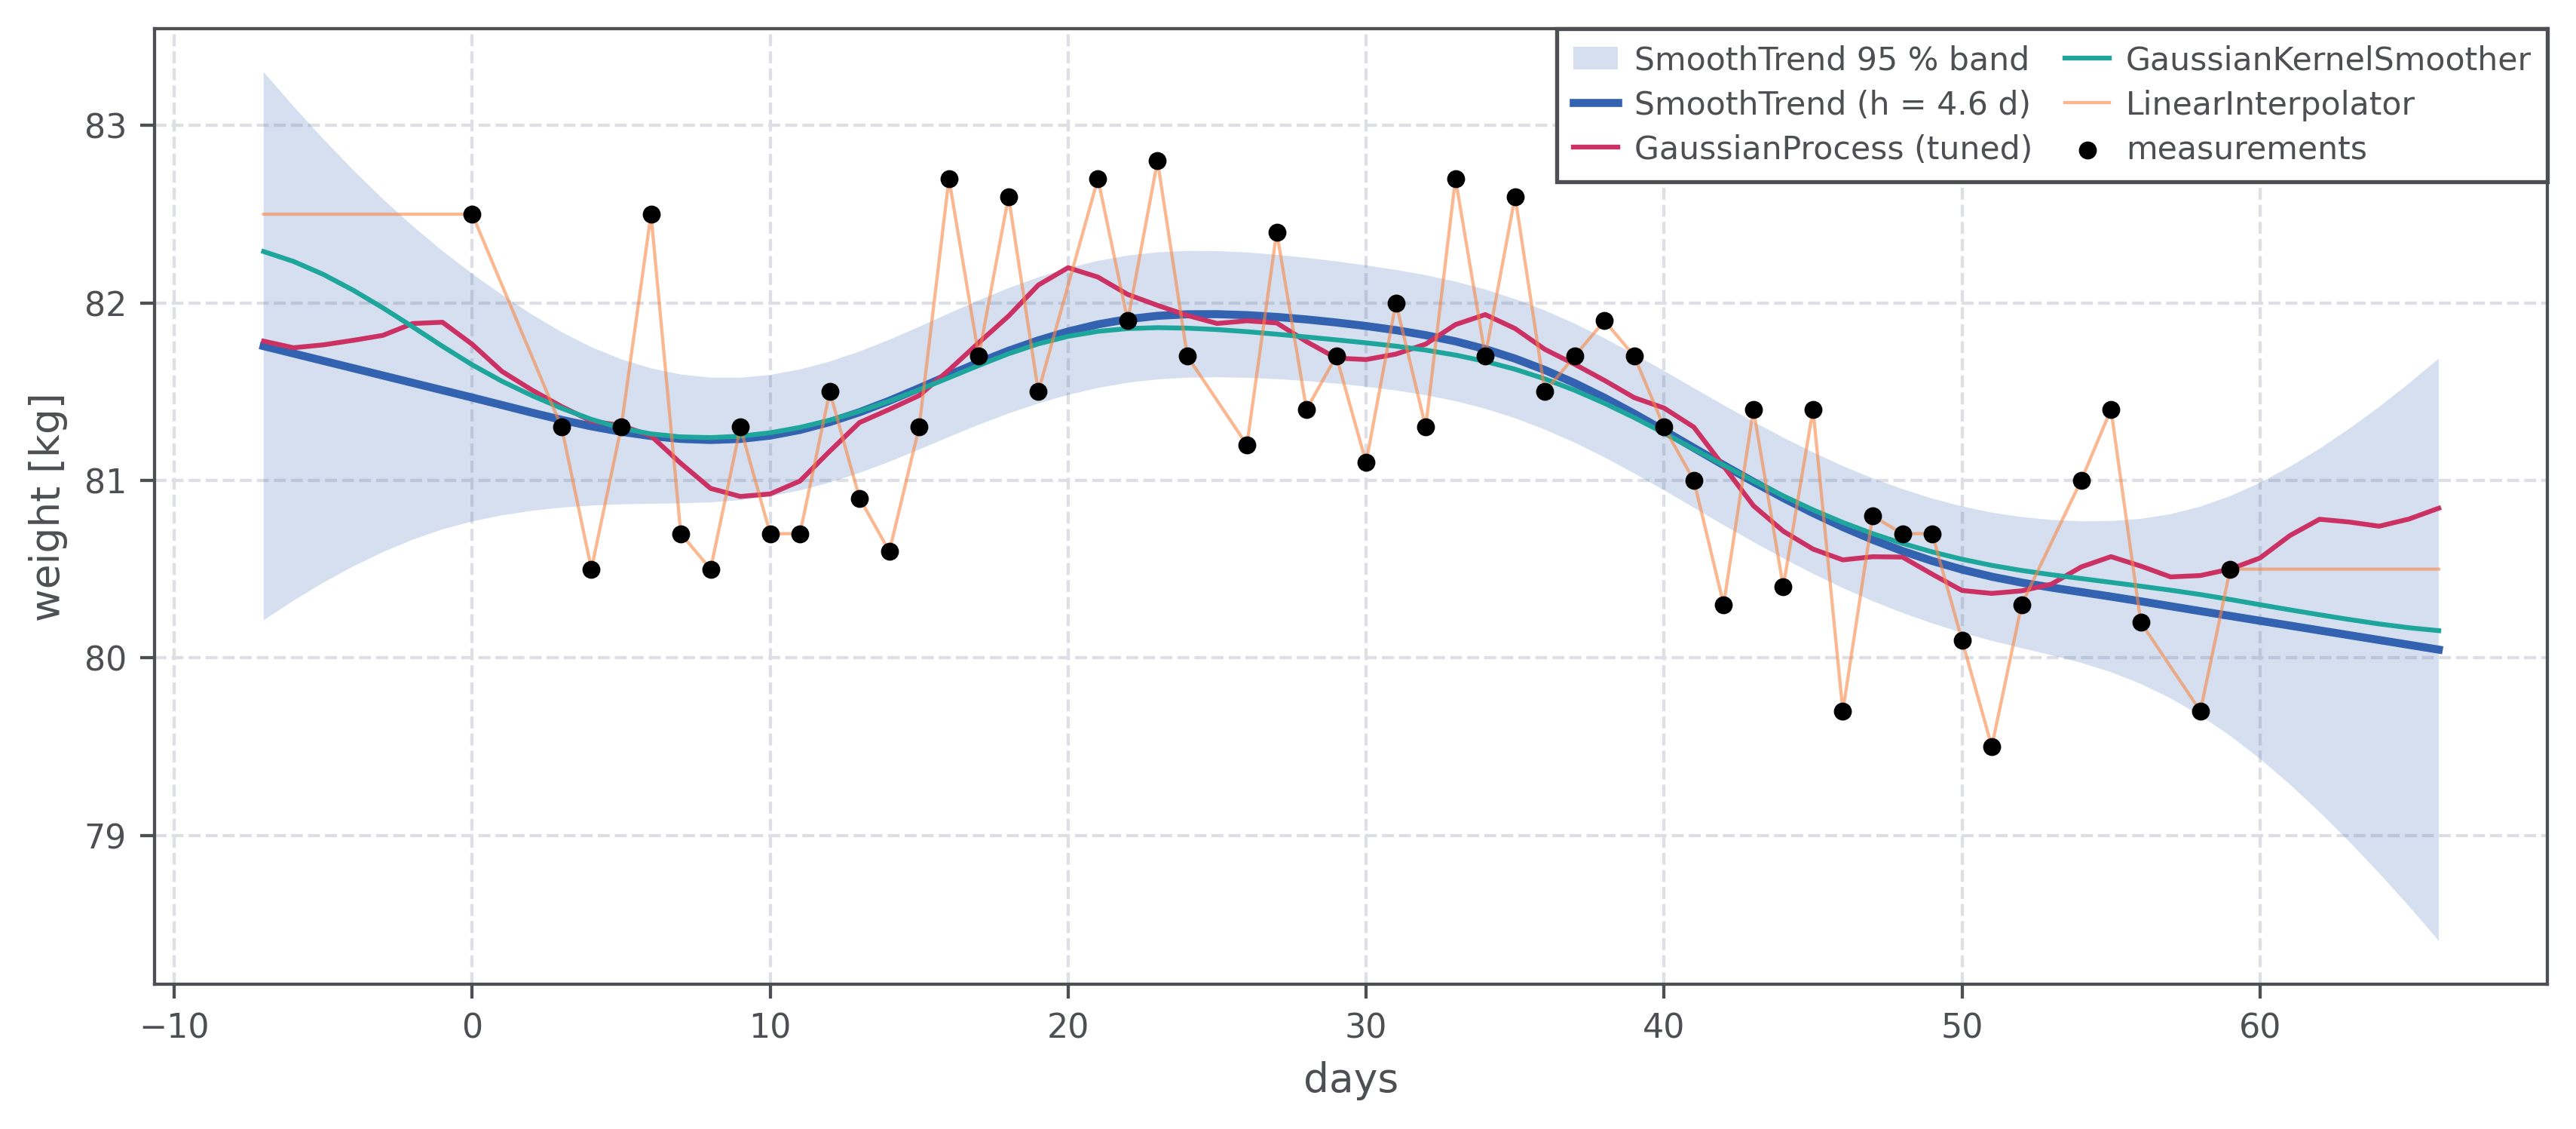

estimated observation noise: 0.62 kg
estimated bandwidth:         4.6 days


In [34]:
times, weights = SERIES["preview"]
grid = np.arange(times.min() - 7, times.max() + 8)

smooth = SmoothTrend().fit(times, weights)
posterior = smooth.smooth(grid)
gp = tuned_gp("preview", times, weights)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(
    grid,
    posterior.mean - 1.96 * posterior.std,
    posterior.mean + 1.96 * posterior.std,
    alpha=0.2,
    label="SmoothTrend 95 % band",
)
ax.plot(
    grid, posterior.mean, lw=2, label=f"SmoothTrend (h = {smooth.bandwidth_:.1f} d)"
)
ax.plot(grid, gp.predict(grid), lw=1.2, label="GaussianProcess (tuned)")
ax.plot(grid, GaussianKernelSmoother().fit(times, weights).predict(grid),
        lw=1.2, label="GaussianKernelSmoother")
ax.plot(grid, LinearInterpolator().fit(times, weights).predict(grid),
        lw=0.8, alpha=0.6, label="LinearInterpolator")
ax.scatter(times, weights, s=12, color="k", zorder=5, label="measurements")
ax.set_xlabel("days")
ax.set_ylabel("weight [kg]")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print(f"estimated observation noise: {smooth.sigma_eps_:.2f} kg")
print(f"estimated bandwidth:         {smooth.bandwidth_:.1f} days")


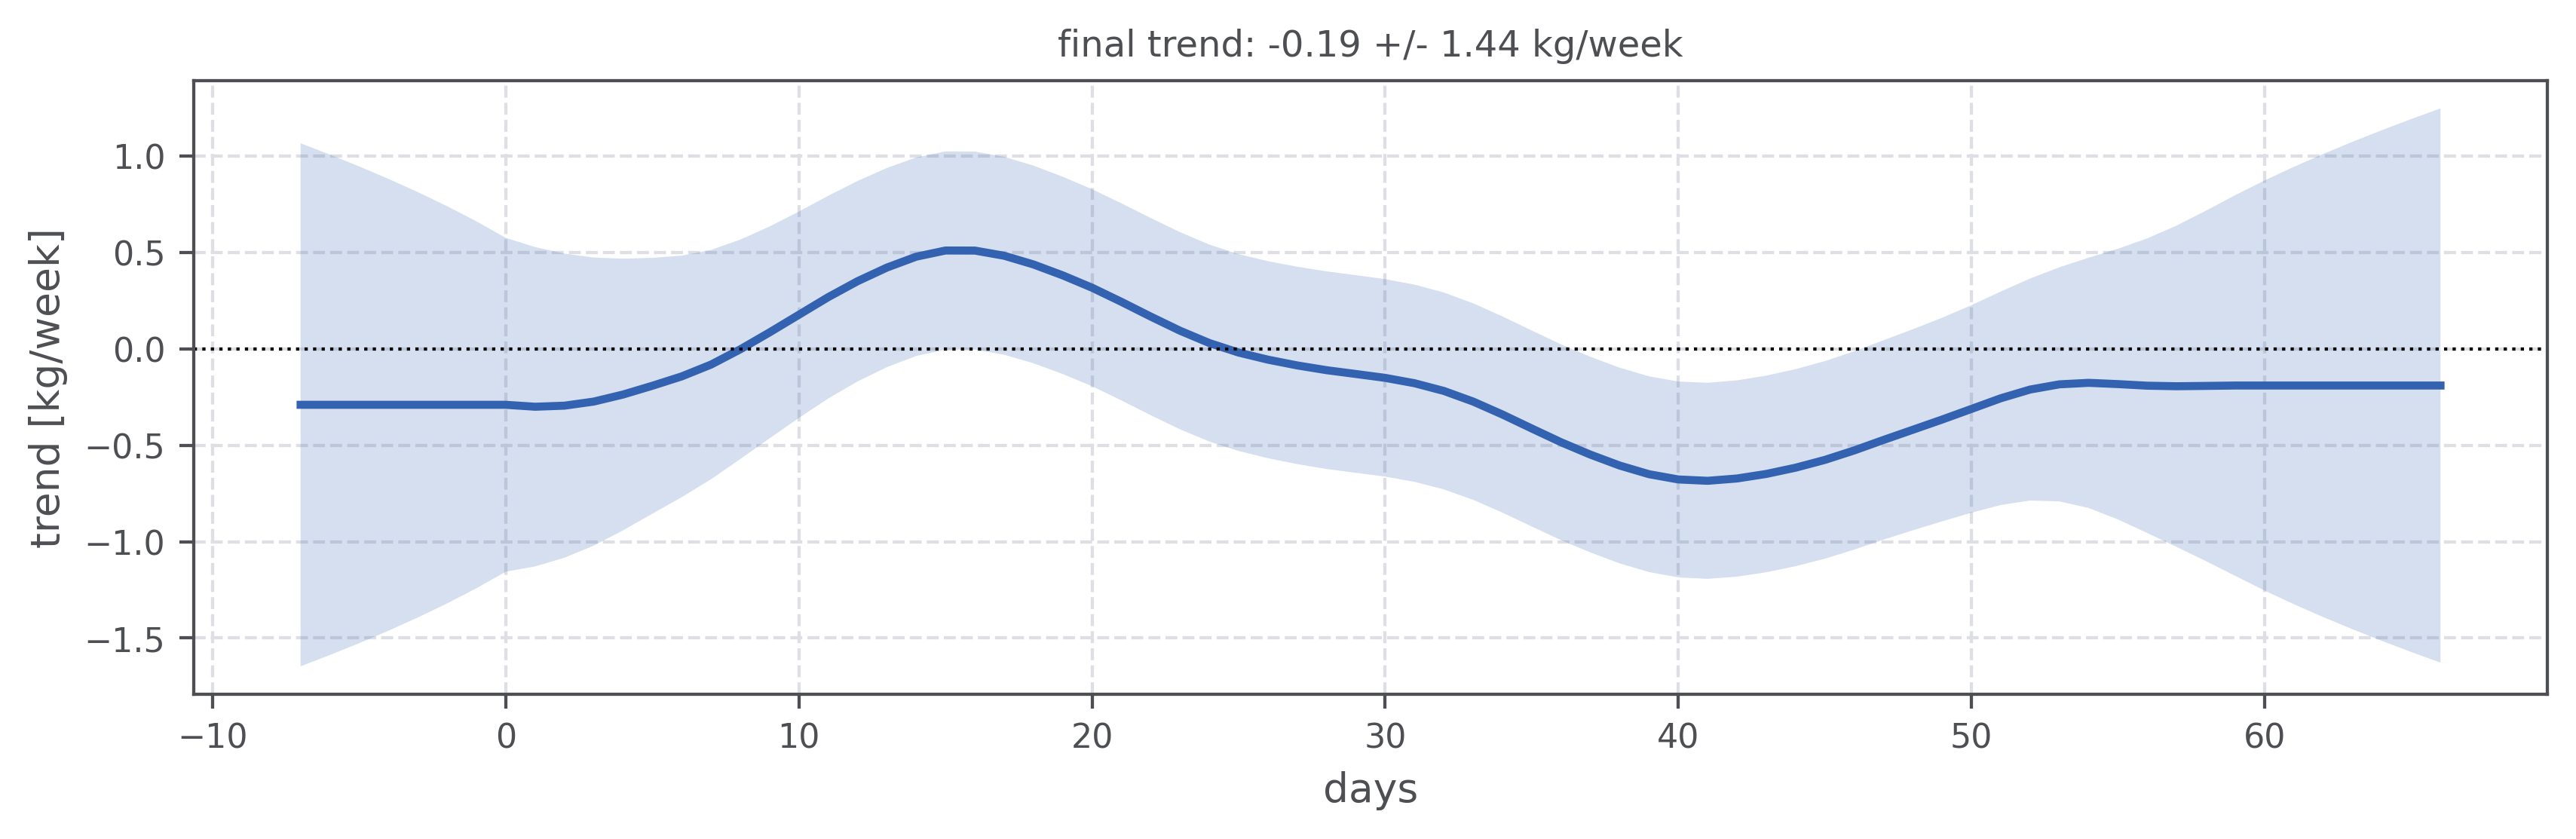

In [35]:
fig, ax = plt.subplots(figsize=(9, 3))
trend = 7 * posterior.trend
band = 7 * 1.96 * posterior.trend_std
ax.fill_between(grid, trend - band, trend + band, alpha=0.2)
ax.plot(grid, trend, lw=2)
ax.axhline(0.0, color="k", lw=0.8, ls=":")
ax.set_xlabel("days")
ax.set_ylabel("trend [kg/week]")
ax.set_title(
    f"final trend: {trend[-1]:+.2f} +/- {band[-1]:.2f} kg/week", fontsize=9
)
plt.tight_layout()
plt.show()


The lower figure is what replaces `_derivative()` in the Dart code. It is
also what issue #93 (*Wrong calculation toward Target Weight*) needs: a rate
with an interval attached can be propagated into an ETA range, and
"+0.4 +/- 0.3 kg/week" is a statement the app can defend.

Note how wide that interval is on 60 days of data. That is not a weakness of
the estimator; it is the honest width, and the current app displays the same
quantity with no interval at all.


---

# §2 — Prospective forecasting (the main metric)

Comparing smoothed curves to each other proves nothing: every method
smooths differently, and "closest to the data" simply rewards whichever
smooths least. The only comparison that means anything is forward chaining —
fit on everything up to day *t*, predict the observation at *t+1*, *t+3*,
*t+7*, never letting the model see the future.

This is exactly what the app promises the user in its seven extrapolated
days.

Two notes before the numbers:

- **`LinearInterpolator` clamps outside the measured range**, so as a
  *forecaster* it is identical to the naive baseline by construction. Both
  are reported anyway; they should agree, and if they do not, something is
  wrong with the harness.
- **The GP gets a concession.** Re-tuning its kernel at every step costs
  ~5 s, which is several hours over a full chain. Its hyperparameters are
  tuned once on the full series and then frozen, so it forecasts with
  hyperparameters fitted on data it has not "seen" yet. That favours the GP.


In [36]:
class NaiveBaseline(Interpolator):
    """Tomorrow you will weigh what you weigh today."""

    def fit(self, times_measured, weights_measured):
        order = np.argsort(times_measured)
        self._last = float(np.asarray(weights_measured)[order][-1])
        return self

    def predict(self, times):
        return np.full(np.asarray(times, float).shape, self._last)


def forward_chain(times, weights, factory, horizons=(1, 3, 7), min_obs=20):
    """Refit on a growing prefix and score genuine out-of-sample forecasts."""
    order = np.argsort(times)
    times, weights = times[order], weights[order]

    records = []
    for i in range(min_obs, len(times)):
        model = factory(times[:i], weights[:i])
        anchor = times[i - 1]

        targets, meta = [], []
        for horizon in horizons:
            j = int(np.searchsorted(times, anchor + horizon - 0.5))
            if j >= i and j < len(times) and abs(times[j] - anchor - horizon) <= 0.5:
                targets.append(times[j])
                meta.append((horizon, j))
        if not targets:
            continue

        predicted = model.predict(np.array(targets))
        std = (
            model.predict_std(np.array(targets))
            if hasattr(model, "predict_std")
            else np.full(len(targets), np.nan)
        )
        for k, (horizon, j) in enumerate(meta):
            records.append((horizon, predicted[k], weights[j], std[k]))

    return np.array(records)


In [37]:
def make_factories(name, times, weights):
    """Build one factory per algorithm, freezing the GP's kernel up front."""
    frozen = tuned_gp(name, times, weights)._gp

    return {
        "naive": lambda t, w: NaiveBaseline().fit(t, w),
        "LinearInterpolator": lambda t, w: LinearInterpolator().fit(t, w),
        "GaussianKernelSmoother": lambda t, w: GaussianKernelSmoother().fit(t, w),
        "GaussianProcess (frozen)": lambda t, w: TunedGaussianProcess(
            frozen=frozen
        ).fit(t, w),
        "SmoothTrend": lambda t, w: SmoothTrend().fit(t, w),
        "SmoothTrend (no reweighting)": lambda t, w: SmoothTrend(robust_c=None).fit(
            t, w
        ),
    }


CHAINS = {}
for name, (times, weights) in SERIES.items():
    if times.size < 40:
        continue
    factories = make_factories(name, times, weights)
    started = time.perf_counter()
    CHAINS[name] = {
        label: forward_chain(times, weights, factory)
        for label, factory in factories.items()
    }
    print(f"{name}: chained in {time.perf_counter() - started:.1f} s")


preview: chained in 0.3 s
synthetic_1y: chained in 5.5 s
synthetic_2y: chained in 27.9 s


In [40]:
def error_table(chain, metric="rmse"):
    horizons = (1, 3, 7)
    print(f"{'algorithm':>30}  " + "  ".join(f"{'h=' + str(h):>8}" for h in horizons))
    for label, records in chain.items():
        cells = []
        for horizon in horizons:
            rows = records[records[:, 0] == horizon]
            residual = rows[:, 1] - rows[:, 2]
            value = (
                np.sqrt(np.mean(residual**2))
                if metric == "rmse"
                else np.mean(np.abs(residual))
            )
            cells.append(f"{value:8.3f}")
        print(f"{label:>30}  " + "  ".join(cells))


for name, chain in CHAINS.items():
    n_points = int((next(iter(chain.values()))[:, 0] == 1).sum())
    print(f"\n=== {name} — RMSE [kg], {n_points} one-day forecasts ===")
    error_table(chain, "rmse")
    print(f"\n=== {name} — MAE [kg] ===")
    error_table(chain, "mae")



=== preview — RMSE [kg], 31 one-day forecasts ===
                     algorithm       h=1       h=3       h=7
                         naive     0.861     0.990     0.973
            LinearInterpolator     0.861     0.990     0.973
        GaussianKernelSmoother     0.621     0.760     0.930
      GaussianProcess (frozen)     0.631     0.775     0.902
                   SmoothTrend     0.666     0.898     1.148
  SmoothTrend (no reweighting)     0.666     0.898     1.148

=== preview — MAE [kg] ===
                     algorithm       h=1       h=3       h=7
                         naive     0.758     0.853     0.768
            LinearInterpolator     0.758     0.853     0.768
        GaussianKernelSmoother     0.500     0.593     0.755
      GaussianProcess (frozen)     0.513     0.627     0.727
                   SmoothTrend     0.586     0.692     0.965
  SmoothTrend (no reweighting)     0.586     0.692     0.965

=== synthetic_1y — RMSE [kg], 101 one-day forecasts ===
          

---

# §3 — Calibration

Only `SmoothTrend` and `GaussianProcess` can be scored here at all, because
only they report an uncertainty. Two questions:

- Does the nominal 95 % interval actually contain 95 % of future
  observations?
- What is the out-of-sample predictive log-likelihood?

The interval being scored is for an **observation**, not for the latent
level, so the observation noise is added back:
`var_obs = var_level + sigma_eps^2`. Forgetting that term is the classic way
to report a band that looks impressively tight and covers 60 % of the data.


In [41]:
def calibration(records, noise_variance):
    total_var = records[:, 3] ** 2 + noise_variance
    residual = records[:, 1] - records[:, 2]
    z = residual / np.sqrt(total_var)
    coverage = float(np.mean(np.abs(z) <= 1.96))
    log_lik = float(
        np.mean(-0.5 * np.log(2 * np.pi * total_var) - 0.5 * residual**2 / total_var)
    )
    return coverage, log_lik


for name, chain in CHAINS.items():
    times, weights = SERIES[name]
    gp_noise = tuned_gp(name, times, weights).noise_variance_
    noise = {
        "SmoothTrend": SmoothTrend().fit(times, weights).sigma_eps_ ** 2,
        "SmoothTrend (no reweighting)": (
            SmoothTrend(robust_c=None).fit(times, weights).sigma_eps_ ** 2
        ),
        "GaussianProcess (frozen)": gp_noise,
    }

    print(f"\n=== {name} ===")
    print(f"{'algorithm':>30}  {'horizon':>7}  {'coverage':>9}  {'pred. logL':>11}")
    for label in (
        "SmoothTrend",
        "SmoothTrend (no reweighting)",
        "GaussianProcess (frozen)",
    ):
        for horizon in (1, 3, 7):
            rows = chain[label][chain[label][:, 0] == horizon]
            coverage, log_lik = calibration(rows, noise[label])
            print(f"{label:>30}  {horizon:7d}  {coverage:8.1%}  {log_lik:11.3f}")



=== preview ===
                     algorithm  horizon   coverage   pred. logL
                   SmoothTrend        1    100.0%       -1.016
                   SmoothTrend        3     93.3%       -1.347
                   SmoothTrend        7     89.3%       -1.812
  SmoothTrend (no reweighting)        1    100.0%       -1.016
  SmoothTrend (no reweighting)        3     93.3%       -1.347
  SmoothTrend (no reweighting)        7     89.3%       -1.812
      GaussianProcess (frozen)        1    100.0%       -0.968
      GaussianProcess (frozen)        3     96.7%       -1.165
      GaussianProcess (frozen)        7     92.9%       -1.316

=== synthetic_1y ===
                     algorithm  horizon   coverage   pred. logL
                   SmoothTrend        1     95.0%       -1.336
                   SmoothTrend        3     93.3%       -1.483
                   SmoothTrend        7     95.8%       -1.475
  SmoothTrend (no reweighting)        1     95.0%       -1.337
  SmoothTrend 

---

# §4 — Cost

The naive benchmark in this repository is misleading in *both* directions,
so it is worth being explicit about what is being measured.

`GaussianKernelSmoother` is `O(N^2)` but written in vectorised NumPy;
`SmoothTrend` is `O(N)` but written as a plain Python loop, because §3.2 of
the design notes requires every line of the main path to be transcribable to
Dart with `dart:math` and `List<double>`. Comparing them directly measures
the quality of NumPy's inner loops, not the algorithms.

The comparison that predicts Dart is **loop against loop**. So three curves:

1. `SmoothTrend` — Python loop, as shipped.
2. `GaussianKernelSmoother` — NumPy, as shipped.
3. `GaussianKernelSmoother` — a straight Python-loop transcription, written
   here in the notebook only, never in `src/`.

Curves 1 and 3 are the pair that matters for the port. Curve 2 is the
footnote that explains why, inside this Python repository, the crossover
against the shipped implementation only arrives around `N ~ 1500`.


In [42]:
def kernel_smoother_loop(times_measured, weights_measured, query, strength=4.0):
    """Loop transcription of `GaussianKernelSmoother`, for timing only.

    Mirrors the shipped pipeline's cost structure: build the daily raster,
    then two Nadaraya-Watson passes, each `O(n^2)` kernel evaluations.
    """
    import math

    pad = 7
    lo = math.floor(times_measured.min()) - pad
    hi = math.floor(times_measured.max()) + pad + 1
    n = int(hi - lo)

    values = [0.0] * n
    counts = [0] * n
    for t, w in zip(times_measured, weights_measured, strict=True):
        idx = int(math.floor(t) - lo)
        values[idx] += w
        counts[idx] += 1
    for i in range(n):
        if counts[i]:
            values[i] /= counts[i]
    sigma = [strength if counts[i] else strength / 2 for i in range(n)]
    rho = [2.0 if counts[i] else 1.0 for i in range(n)]

    current = values
    for _ in range(2):
        smoothed = [0.0] * n
        for i in range(n):
            if current[i] == 0.0:
                continue
            total = 0.0
            weighted = 0.0
            for j in range(n):
                if current[j] == 0.0:
                    continue
                d = float(i - j)
                k = (
                    math.exp(-d * d / (2 * sigma[j] * sigma[j]))
                    / (sigma[j] * math.sqrt(2 * math.pi))
                    * rho[j]
                )
                total += k
                weighted += k * current[j]
            smoothed[i] = weighted / total
        current = smoothed

    return [current[min(n - 1, max(0, int(math.floor(t) - lo)))] for t in query]


In [43]:
SIZES = (60, 180, 365, 730, 1500)
rng = np.random.default_rng(0)
timings = {"SmoothTrend fit": [], "SmoothTrend predict": [],
           "GaussianKernelSmoother (numpy)": [], "GaussianKernelSmoother (loop)": []}

for n_days in SIZES:
    times, weights, _ = synthetic_history(n_days=n_days, seed=3, outlier_rate=0.0)
    query = np.arange(-7, n_days + 7.0)

    started = time.perf_counter()
    model = SmoothTrend().fit(times, weights)
    timings["SmoothTrend fit"].append(time.perf_counter() - started)

    started = time.perf_counter()
    model.smooth(query)
    timings["SmoothTrend predict"].append(time.perf_counter() - started)

    started = time.perf_counter()
    GaussianKernelSmoother().fit(times, weights).predict(query)
    timings["GaussianKernelSmoother (numpy)"].append(time.perf_counter() - started)

    started = time.perf_counter()
    kernel_smoother_loop(times, weights, query)
    timings["GaussianKernelSmoother (loop)"].append(time.perf_counter() - started)

    print(f"n_days = {n_days:5d} done")


n_days =    60 done
n_days =   180 done
n_days =   365 done
n_days =   730 done


/home/elias/Documentos/pytrale/src/pytrale/algorithms/gaussian_kernel.py:124: RuntimeWarning: divide by zero encountered in divide
  gaussian_weights / gaussian_weights[ms > 0].sum(),
/home/elias/Documentos/pytrale/src/pytrale/algorithms/gaussian_kernel.py:124: RuntimeWarning: invalid value encountered in divide
  gaussian_weights / gaussian_weights[ms > 0].sum(),
/home/elias/Documentos/pytrale/src/pytrale/algorithms/gaussian_kernel.py:124: RuntimeWarning: overflow encountered in divide
  gaussian_weights / gaussian_weights[ms > 0].sum(),


n_days =  1500 done


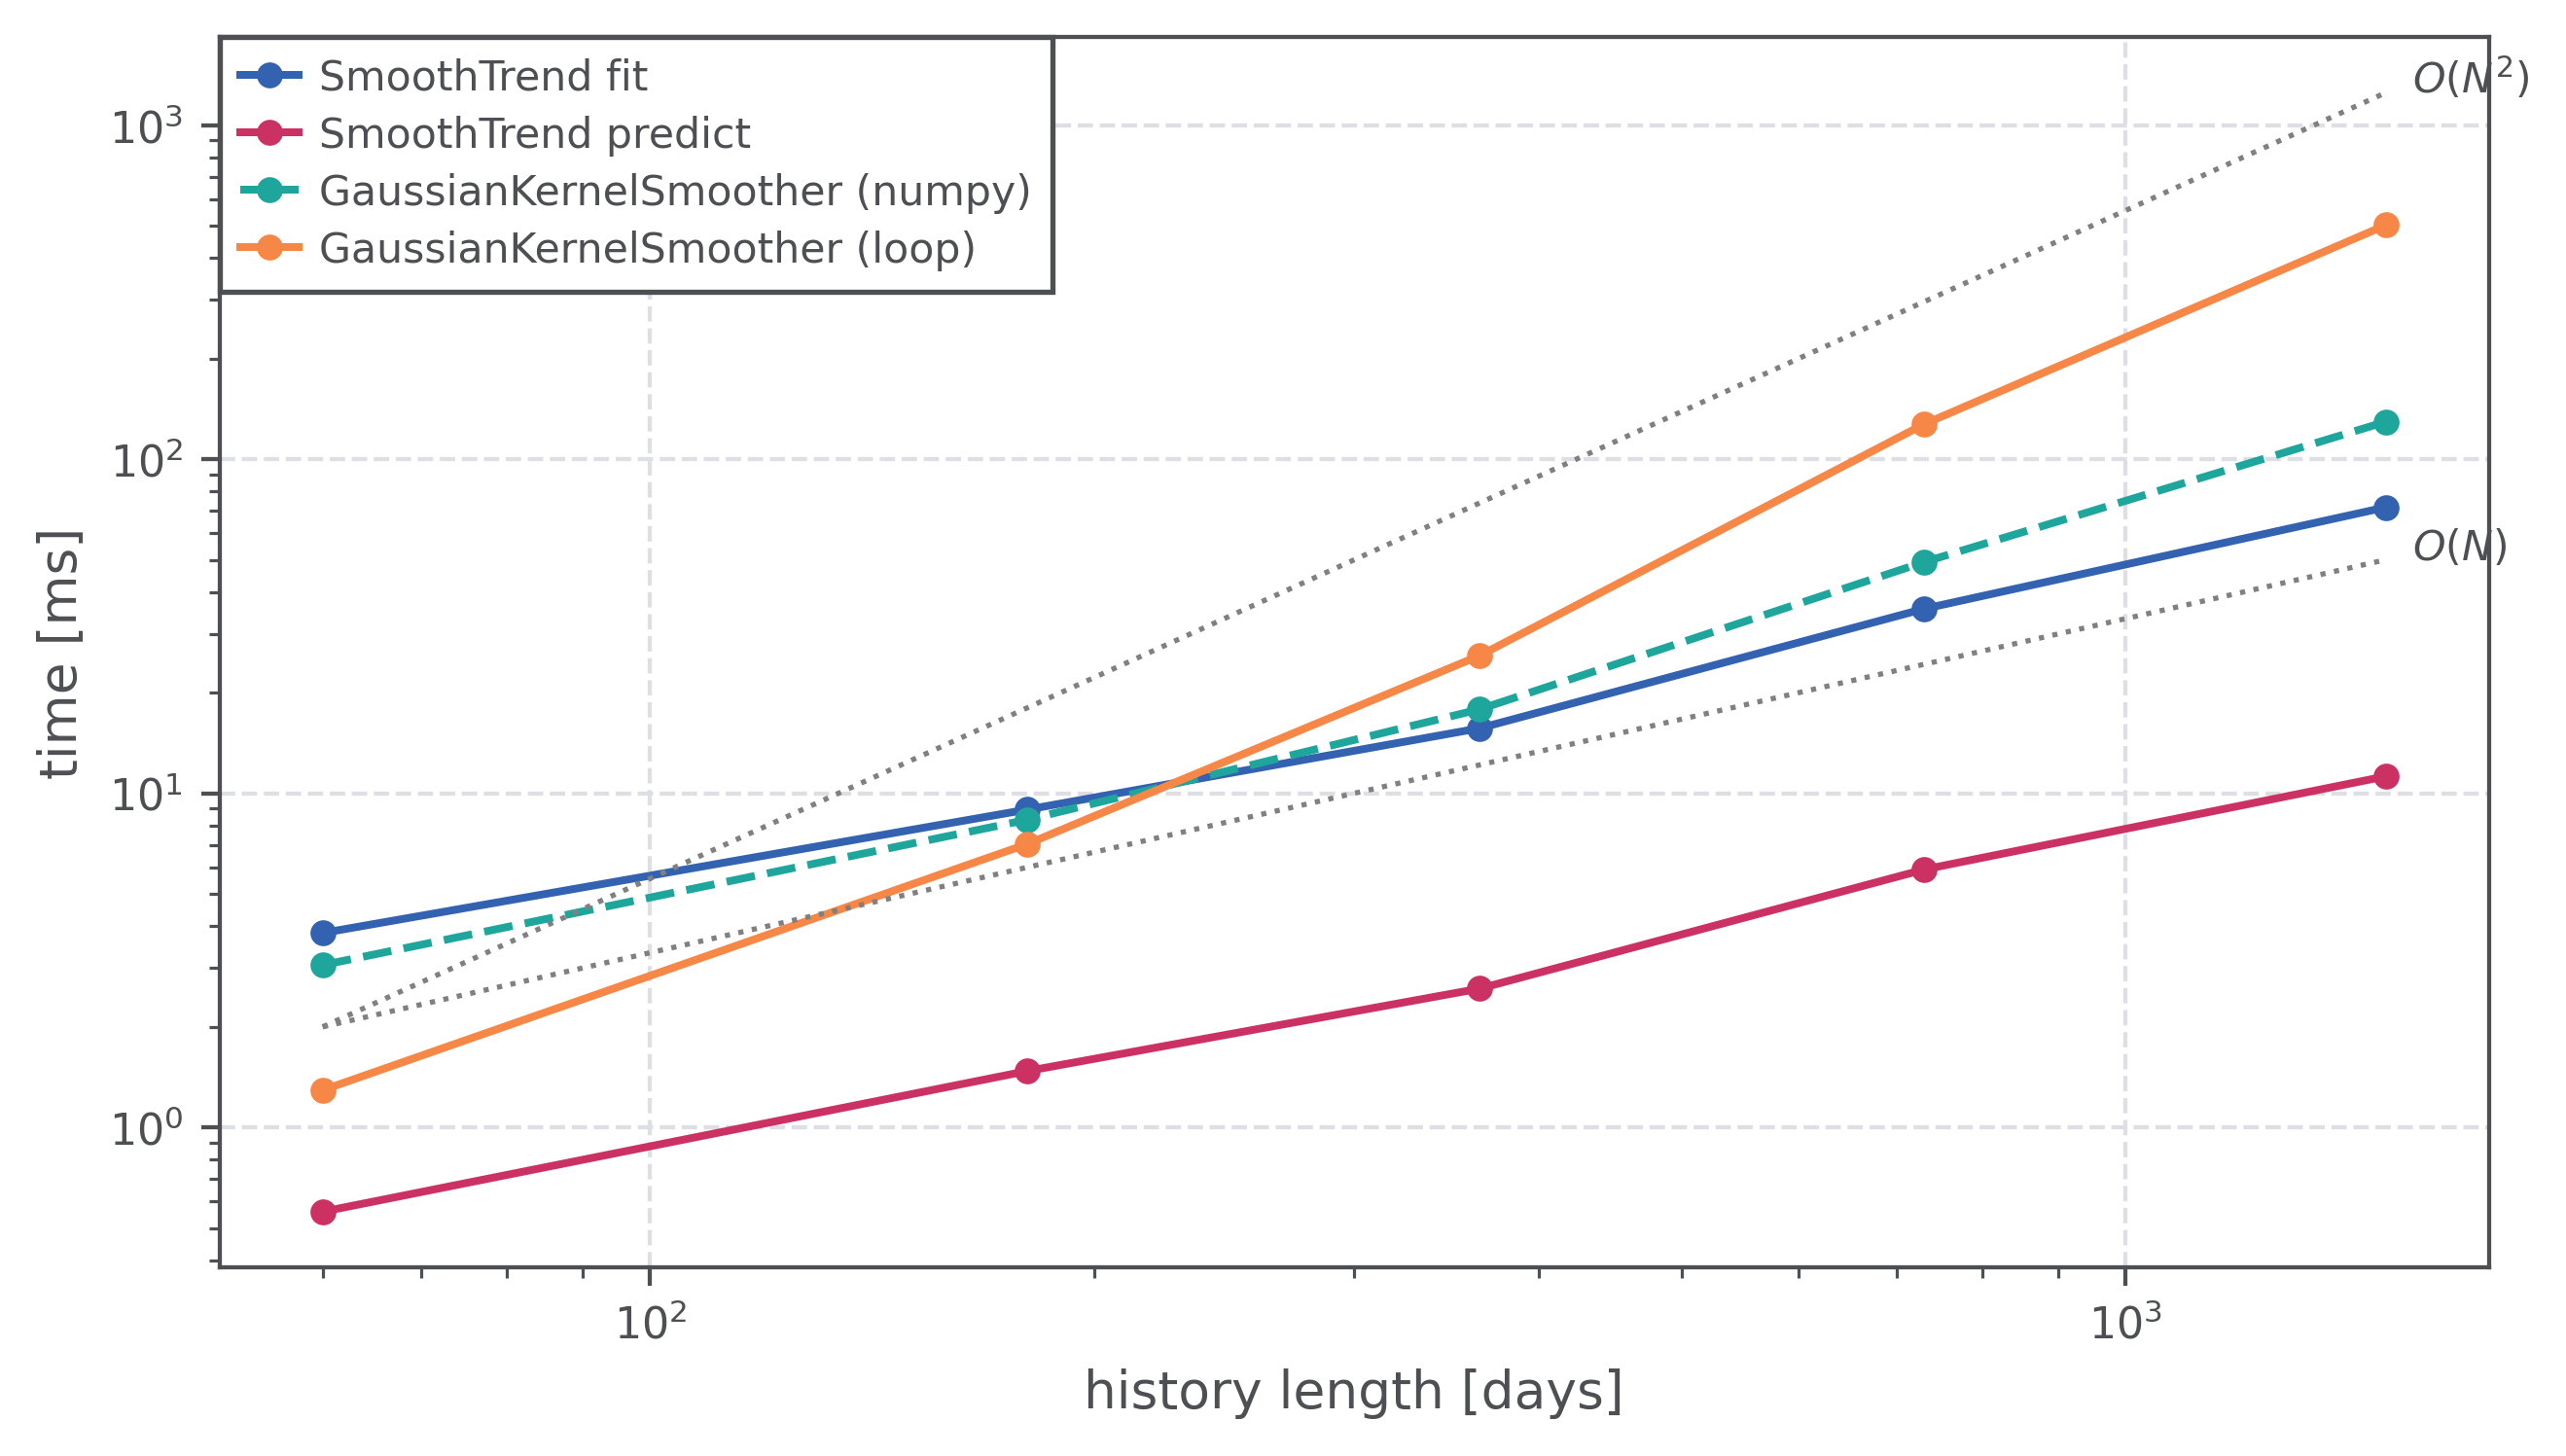

 n_days     ST fit   ST predict    GKS loop   first draw   per redraw
     60       3.8ms         0.6ms        1.3ms         0.3x         2.3x
    180       8.9ms         1.5ms        7.0ms         0.7x         4.8x
    365      15.7ms         2.6ms       25.9ms         1.4x         9.9x
    730      35.7ms         5.9ms      127.3ms         3.1x        21.5x
   1500      71.8ms        11.2ms      501.8ms         6.0x        44.6x


In [44]:
fig, ax = plt.subplots(figsize=(7, 4))
for label, values in timings.items():
    style = "--" if "numpy" in label else "-"
    ax.loglog(SIZES, np.array(values) * 1e3, style, marker="o", ms=4, label=label)

reference = np.array(SIZES, dtype=float)
ax.loglog(SIZES, reference / reference[0] * 2, ":", color="grey", lw=1)
ax.loglog(SIZES, (reference / reference[0]) ** 2 * 2, ":", color="grey", lw=1)
ax.text(SIZES[-1], reference[-1] / reference[0] * 2, r"  $O(N)$", fontsize=8)
ax.text(SIZES[-1], (SIZES[-1] / SIZES[0]) ** 2 * 2, r"  $O(N^2)$", fontsize=8)
ax.set_xlabel("history length [days]")
ax.set_ylabel("time [ms]")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(
    f"{'n_days':>7}  {'ST fit':>9}  {'ST predict':>11}  {'GKS loop':>10}  "
    f"{'first draw':>11}  {'per redraw':>11}"
)
for i, n_days in enumerate(SIZES):
    fit = timings["SmoothTrend fit"][i]
    predict = timings["SmoothTrend predict"][i]
    loop = timings["GaussianKernelSmoother (loop)"][i]
    print(
        f"{n_days:7d}  {fit * 1e3:8.1f}ms  {predict * 1e3:10.1f}ms  "
        f"{loop * 1e3:9.1f}ms  {loop / (fit + predict):10.1f}x  {loop / predict:10.1f}x"
    )


In [45]:
print(f"{'n_days':>7}  {'GKS flops':>12}  {'ST fit flops':>13}  {'ST predict':>12}")
for n_days in SIZES:
    n_grid = n_days + 14
    n_obs = int(n_days * 4 / 7)
    # ~40 flops per kernel evaluation (exp included), two Nadaraya-Watson passes.
    kernel_flops = 2 * n_grid**2 * 40
    # ~30 flops per filter step; the grid of 40 evaluates the filter only.
    fit_flops = 40 * n_obs * 30
    # Filter plus smoother over the union of measurements and query points.
    predict_flops = (n_obs + n_grid) * 60
    print(
        f"{n_days:7d}  {kernel_flops:12,d}  {fit_flops:13,d}  {predict_flops:12,d}"
    )


 n_days     GKS flops   ST fit flops    ST predict
     60       438,080         40,800         6,480
    180     3,010,880        122,400        17,760
    365    11,491,280        249,600        35,220
    730    44,282,880        500,400        69,660
   1500   183,375,680      1,028,400       142,260


A side observation from the sweep: at `n_days = 1500` the shipped
`GaussianKernelSmoother` emits `divide by zero` and `invalid value` warnings
from `gaussian_kernel.py:124`. With a 4-day bandwidth over a raster of 1500+
points the Gaussian weights underflow to exactly zero for distant points and
the normalisation divides by zero. That is a real limitation of the `O(N^2)`
kernel on long histories, not an artefact of this notebook.

Read the flop table, not the wall clock: it is what transcribes to Dart, and
it is the number a reviewer can check mentally. Fitting the hyperparameters
— all forty filter passes of them — costs less than a *single* evaluation of
the algorithm the app runs today, which never fits anything. The recurring
cost, the one paid on every repaint, is the `predict` column.

The separation matters for the port too: `fit` runs once when the data
changes, `predict` runs per redraw. Neither justifies an isolate.


---

# §5 — Robustness

Three experiments, because the first one alone would be too flattering.

The reweighting in `SmoothTrend` inflates an outlying observation's noise
variance by `(z/c)^2`. That is one IRLS step of a Student-t likelihood with
`c^2 - 1` degrees of freedom (about 5.3 at the default `c = 2.5`) — which
means the influence function *redescends* to zero rather than merely being
bounded, as it would be under Huber weighting. Redescending estimators buy
more protection and cost more risk, and §5.2 is where that risk is tested.


                     algorithm   max shift [kg]
            LinearInterpolator            2.000
        GaussianKernelSmoother            0.238
  SmoothTrend (no reweighting)            0.088
                   SmoothTrend            0.059


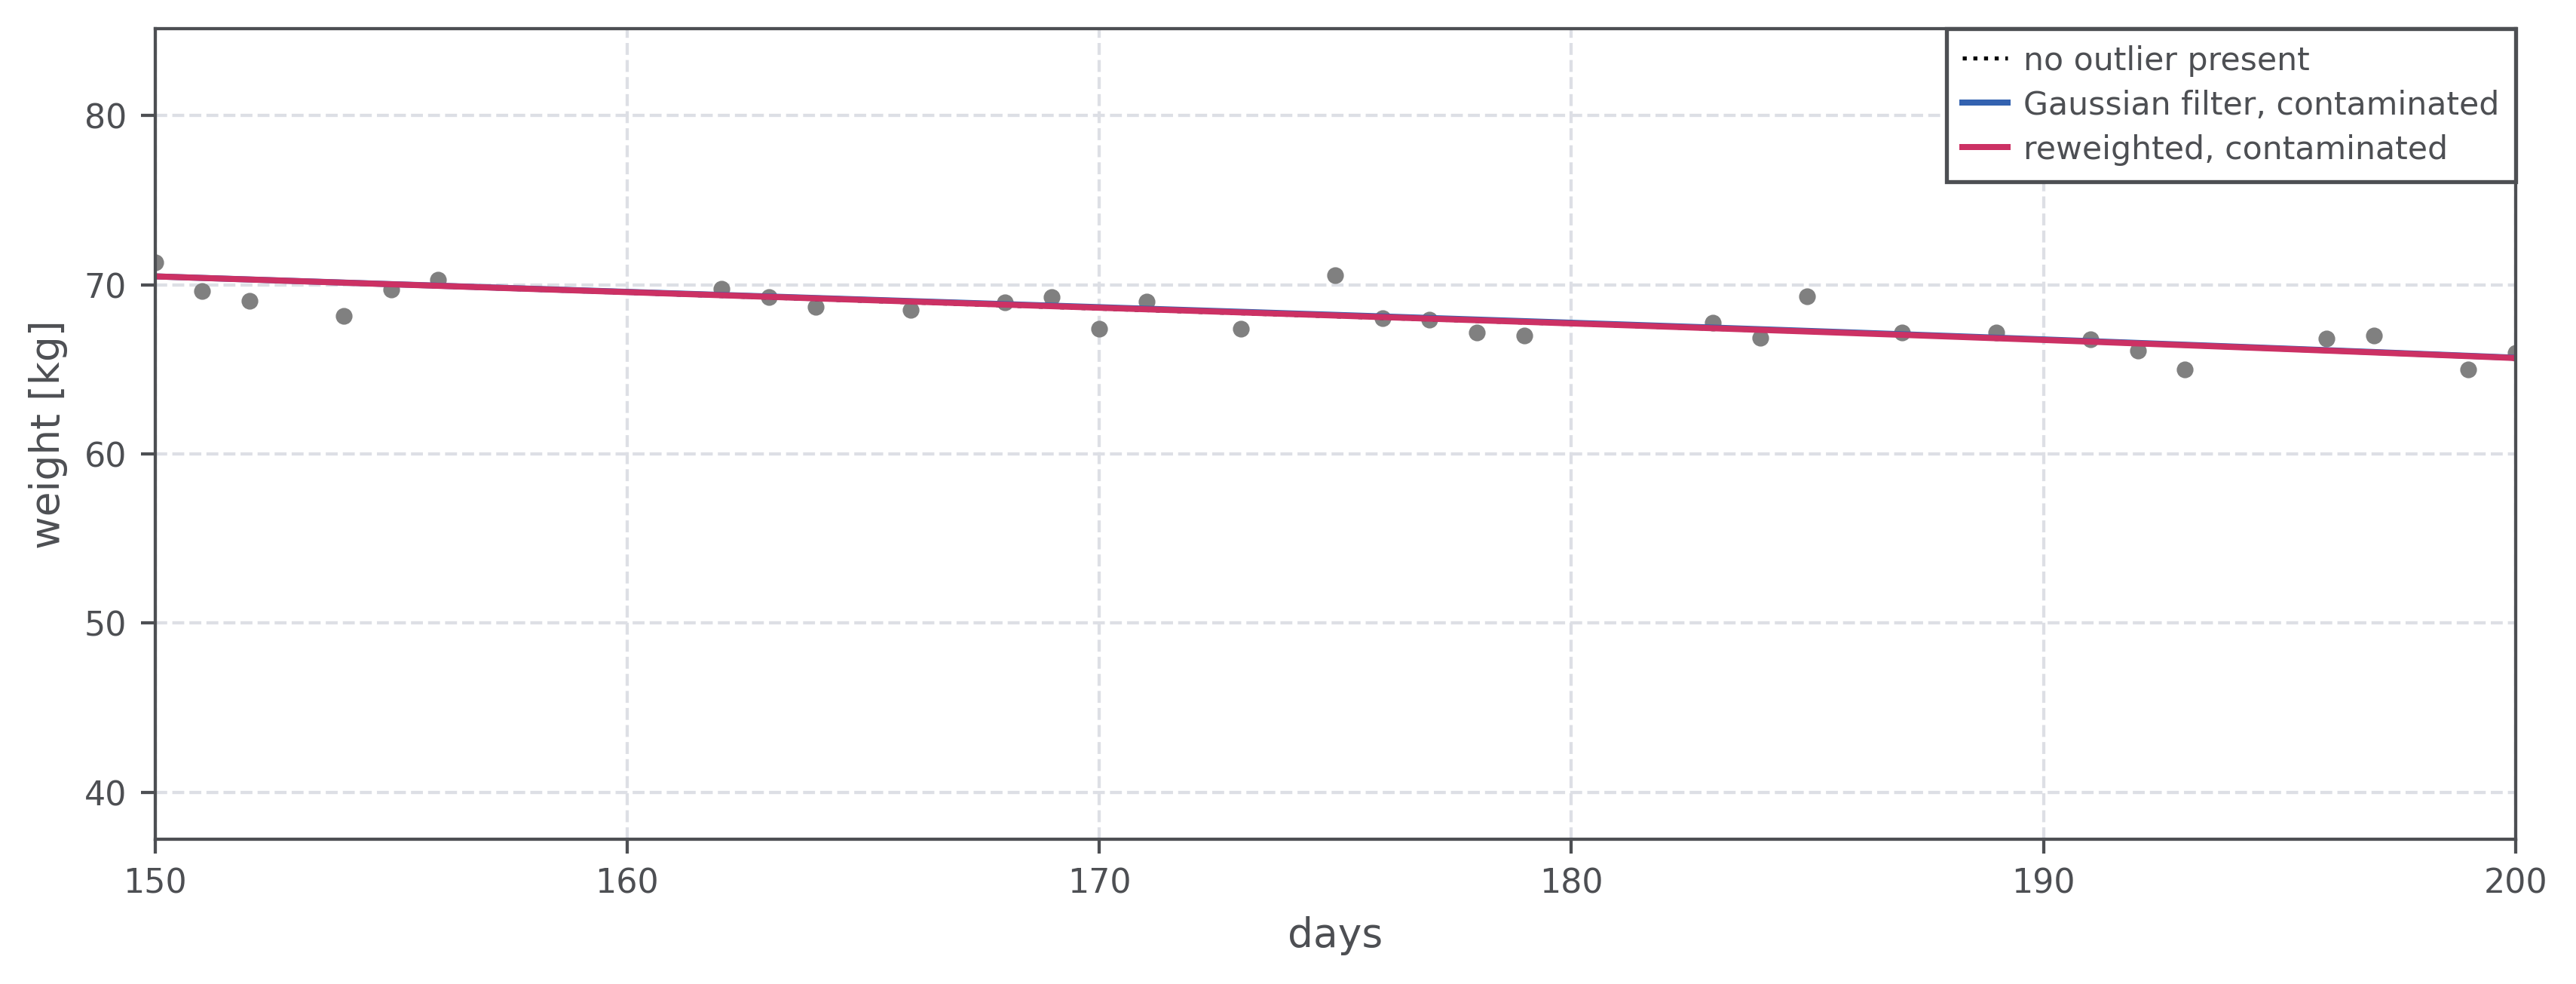

In [46]:
# The stock synthetic series already carries 2 % gross errors, which would
# confound the comparison; this one is clean apart from the injected outlier.
times, weights, _ = synthetic_history(n_days=365, seed=11, outlier_rate=0.0)
grid = np.arange(times.min(), times.max() + 1)

contaminated = weights.copy()
victim = len(times) // 2
contaminated[victim] += 2.0

print(f"{'algorithm':>30}  {'max shift [kg]':>15}")
for label, build in (
    ("LinearInterpolator", lambda t, w: LinearInterpolator().fit(t, w)),
    ("GaussianKernelSmoother", lambda t, w: GaussianKernelSmoother().fit(t, w)),
    (
        "SmoothTrend (no reweighting)",
        lambda t, w: SmoothTrend(robust_c=None).fit(t, w),
    ),
    ("SmoothTrend", lambda t, w: SmoothTrend().fit(t, w)),
):
    clean = build(times, weights).predict(grid)
    dirty = build(times, contaminated).predict(grid)
    print(f"{label:>30}  {np.abs(dirty - clean).max():15.3f}")

fig, ax = plt.subplots(figsize=(9, 3.5))
window = (times[victim] - 25 <= grid) & (grid <= times[victim] + 25)
plain = SmoothTrend(robust_c=None)
ax.plot(
    grid[window], plain.fit(times, weights).predict(grid)[window],
    color="k", lw=1, ls=":", label="no outlier present",
)
ax.plot(
    grid[window], plain.fit(times, contaminated).predict(grid)[window],
    label="Gaussian filter, contaminated",
)
ax.plot(
    grid[window], SmoothTrend().fit(times, contaminated).predict(grid)[window],
    label="reweighted, contaminated",
)
ax.scatter(times, contaminated, s=10, color="grey")
ax.set_xlim(times[victim] - 25, times[victim] + 25)
ax.set_xlabel("days")
ax.set_ylabel("weight [kg]")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## §5.2 — Does the reweighting reject a *genuine* change?

This is the failure mode a redescending estimator has and a bounded one does
not. If someone starts a hard diet, catches a stomach bug, or changes
medication, several consecutive innovations can exceed `c` standard
deviations while `p11_pred` is still small. A filter that discounts them all
would refuse to follow a real change.

The experiment injects a genuine 3 kg drop over 5 days into densely sampled
data and sweeps `robust_c`. What matters is the lag before the curve catches
up, not the smoothness.


pre-step fit: h = 9.5 d, sigma_eps = 0.50 kg
free refit:   h = 3.2 d, sigma_eps = 0.53 kg

  robust_c    days to close the step   residual bias
       2.0                                21          -0.050
       2.5                                19          -0.037
       3.0                                18          -0.025
      None                                16          -0.011


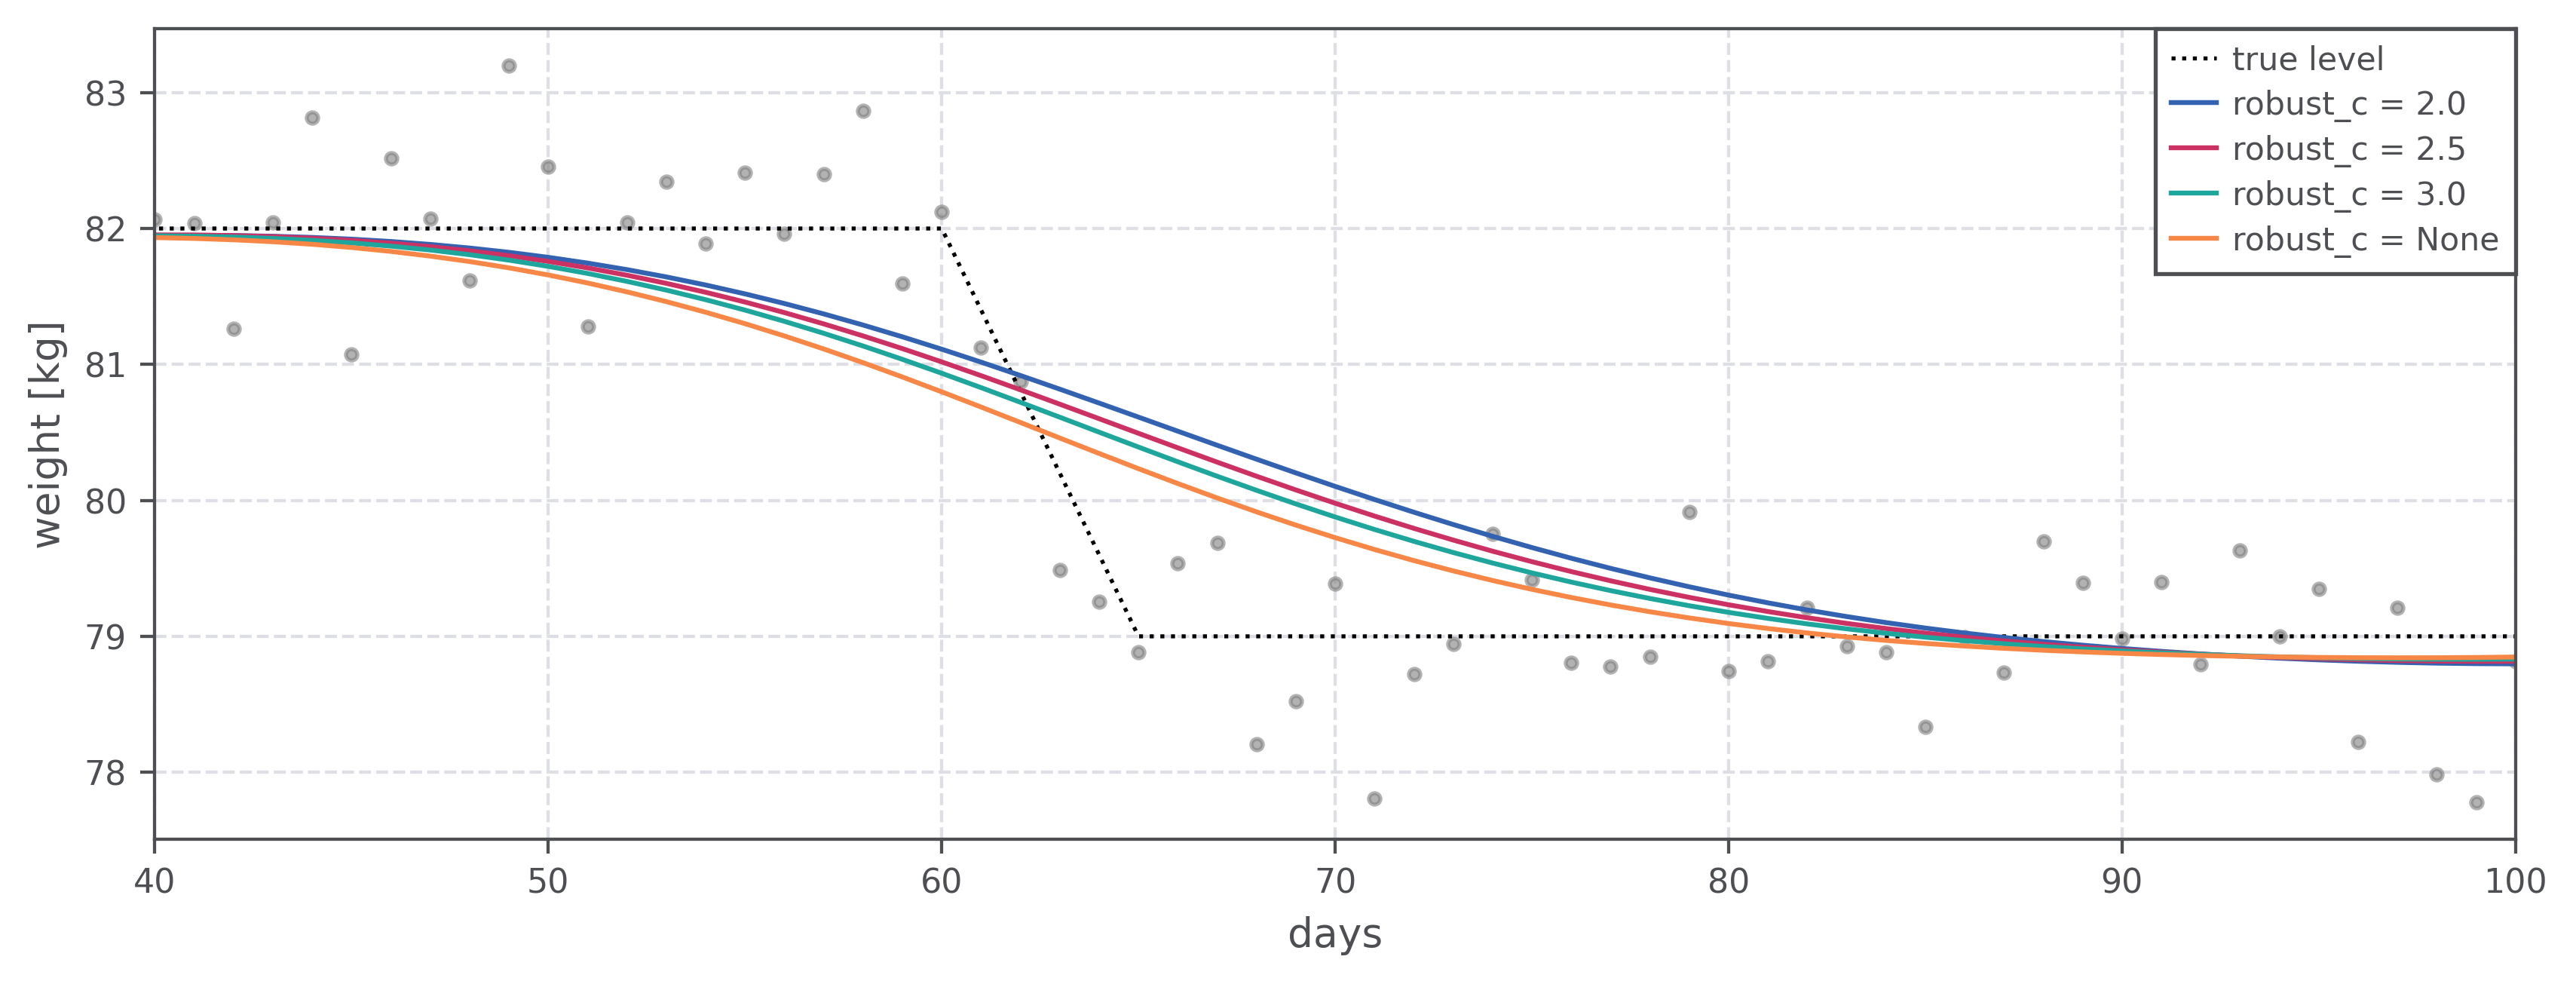

In [47]:
rng = np.random.default_rng(7)
days = np.arange(120.0)
truth = 82.0 - 3.0 * np.clip((days - 60) / 5.0, 0.0, 1.0)
observed = truth + rng.normal(0.0, 0.6, days.size)

# The hyperparameters are frozen on the quiet stretch *before* the step. Left
# free, the fit simply shortens the bandwidth to absorb the drop, which hides
# the very failure mode this section is meant to expose — and is itself worth
# knowing: an adaptive fit is its own protection.
before = SmoothTrend().fit(days[days < 60], observed[days < 60])
print(
    f"pre-step fit: h = {before.bandwidth_:.1f} d, "
    f"sigma_eps = {before.sigma_eps_:.2f} kg"
)
free = SmoothTrend().fit(days, observed)
print(
    f"free refit:   h = {free.bandwidth_:.1f} d, "
    f"sigma_eps = {free.sigma_eps_:.2f} kg"
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(days, truth, color="k", lw=1, ls=":", label="true level")
ax.scatter(days, observed, s=8, color="grey", alpha=0.6)

target = truth[0] - 0.9 * 3.0
print(
    f"\n{'robust_c':>10}  {'days to close the step':>24}  {'residual bias':>14}"
)
for robust_c in (2.0, 2.5, 3.0, None):
    model = SmoothTrend(
        lam=before.lam_, sigma_eps=before.sigma_eps_, robust_c=robust_c
    ).fit(days, observed)
    curve = model.predict(days)
    after, after_days = curve[days >= 60], days[days >= 60]
    reached = after_days[np.argmax(after <= target)] - 60 if np.any(
        after <= target
    ) else None
    lag = "never" if reached is None else f"{reached:.0f}"
    bias = curve[-1] - truth[-1]
    print(f"{str(robust_c):>10}  {lag:>32}  {bias:+14.3f}")
    ax.plot(days, curve, lw=1.2, label=f"robust_c = {robust_c}")

ax.set_xlim(40, 100)
ax.set_xlabel("days")
ax.set_ylabel("weight [kg]")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## §5.3 — Does an outlier contaminate the hyperparameters?

`lam` and `sigma_eps` are estimated with the *plain Gaussian* filter, so that
the likelihood being maximised is the model's own. The price is that an
outlier inflates the residual sum, raises `sigma_eps` and pushes `lam`
towards more smoothing. The reweighting then runs with hyperparameters that
were themselves contaminated.

If that shift turns out to be large, the decision is worth revisiting — fit,
reweight, refit once would cost one extra grid sweep.


In [48]:
print(f"{'series':>14}  {'contamination':>14}  {'h [d]':>7}  {'sigma_eps [kg]':>15}")
for name, (times, weights) in SERIES.items():
    if times.size < 40:
        continue
    for label in ("clean", "+2 kg outlier"):
        series = weights.copy()
        if label != "clean":
            series[len(series) // 2] += 2.0
        model = SmoothTrend().fit(times, series)
        print(
            f"{name:>14}  {label:>14}  {model.bandwidth_:7.1f}  "
            f"{model.sigma_eps_:15.3f}"
        )


        series   contamination    h [d]   sigma_eps [kg]
       preview           clean      4.6            0.618
       preview   +2 kg outlier      4.8            0.684
  synthetic_1y           clean      7.8            0.864
  synthetic_1y   +2 kg outlier      7.8            0.855
  synthetic_2y           clean      9.2            0.816
  synthetic_2y   +2 kg outlier      9.2            0.815


---

# §6 — Sensitivity to `trend_prior_variance`

`SmoothTrend` is not diffuse-initialised. It uses a proper prior on the
initial rate, `P[1,1] = trend_prior_variance * sigma_eps^2`, with a default
of 0.035 day^-2 — roughly `(0.15 kg/day)^2` at a typical `sigma_eps` of
0.8 kg. Expressing it *relative to the noise* is what keeps the
concentration of the scale exact; expressing it in absolute kg^2/day^2 would
break the derivation in §0.

The consequence is that `lam` is formally a MAP estimate under that prior
rather than a diffuse ML estimate, so the constant deserves a sensitivity
check. If the fit barely moves across an order of magnitude, the last open
choice in the procedure is closed.


In [49]:
priors = (0.01, 0.02, 0.035, 0.06, 0.1)
print(f"{'series':>14}  " + "  ".join(f"{p:>9}" for p in priors))
for name, (times, weights) in SERIES.items():
    bandwidths = [
        SmoothTrend(trend_prior_variance=p).fit(times, weights).bandwidth_
        for p in priors
    ]
    cells = "  ".join(f"{h:9.2f}" for h in bandwidths)
    spread = max(bandwidths) / min(bandwidths) - 1
    print(f"{name:>14}  {cells}   (spread {spread:.1%})")


        series       0.01       0.02      0.035       0.06        0.1
       preview       5.11       4.85       4.64       4.45       4.30   (spread 18.9%)
  synthetic_1y       7.87       7.85       7.84       7.83       7.83   (spread 0.5%)
  synthetic_2y       9.24       9.25       9.25       9.25       9.25   (spread 0.2%)


---

# §7 — Reproducing the current look

The biggest non-technical risk of this change is that curves shift and users
notice. Silverman's (1984) equivalent-kernel result gives the bridge: the
smoothing spline behaves like a kernel of width `h = (sigma_eps^2/q)^(1/4)`,
which in this parametrisation is exactly `h = lam^(-1/4)`.

So for each of trale's four `InterpolStrength` levels there is a `lam` that
reproduces the current appearance. The sweep below finds it by matching
curves directly, and compares the answer with the analytic prediction
`sigma_eff = sigma * sqrt(2)` from the two-pass Gaussian filter.


In [50]:
times, weights = SERIES["synthetic_1y"]
grid = np.arange(times.min() - 7, times.max() + 8)
sigma_hat = SmoothTrend().fit(times, weights).sigma_eps_
candidates = np.linspace(1.5, 25.0, 120)

print(
    f"{'strength':>10}  {'sigma':>6}  {'sigma_eff':>10}  {'matched h':>10}  {'rms':>7}"
)
matched = {}
for label, strength in (("soft", 2.0), ("medium", 4.0), ("strong", 7.0)):
    target = (
        GaussianKernelSmoother(
            interpol_strength_measurement=strength,
            interpol_strength_interpol=strength / 2,
        )
        .fit(times, weights)
        .predict(grid)
    )
    errors = [
        np.sqrt(
            np.mean(
                (
                    SmoothTrend(lam=h**-4.0, sigma_eps=sigma_hat, robust_c=None)
                    .fit(times, weights)
                    .predict(grid)
                    - target
                )
                ** 2
            )
        )
        for h in candidates
    ]
    best = candidates[int(np.argmin(errors))]
    matched[label] = (best, target)
    print(
        f"{label:>10}  {strength:6.1f}  {strength * np.sqrt(2):10.2f}  "
        f"{best:10.2f}  {min(errors):7.3f}"
    )


  strength   sigma   sigma_eff   matched h      rms
      soft     2.0        2.83        2.68    0.165
    medium     4.0        5.66        6.63    0.208
    strong     7.0        9.90       15.52    0.270


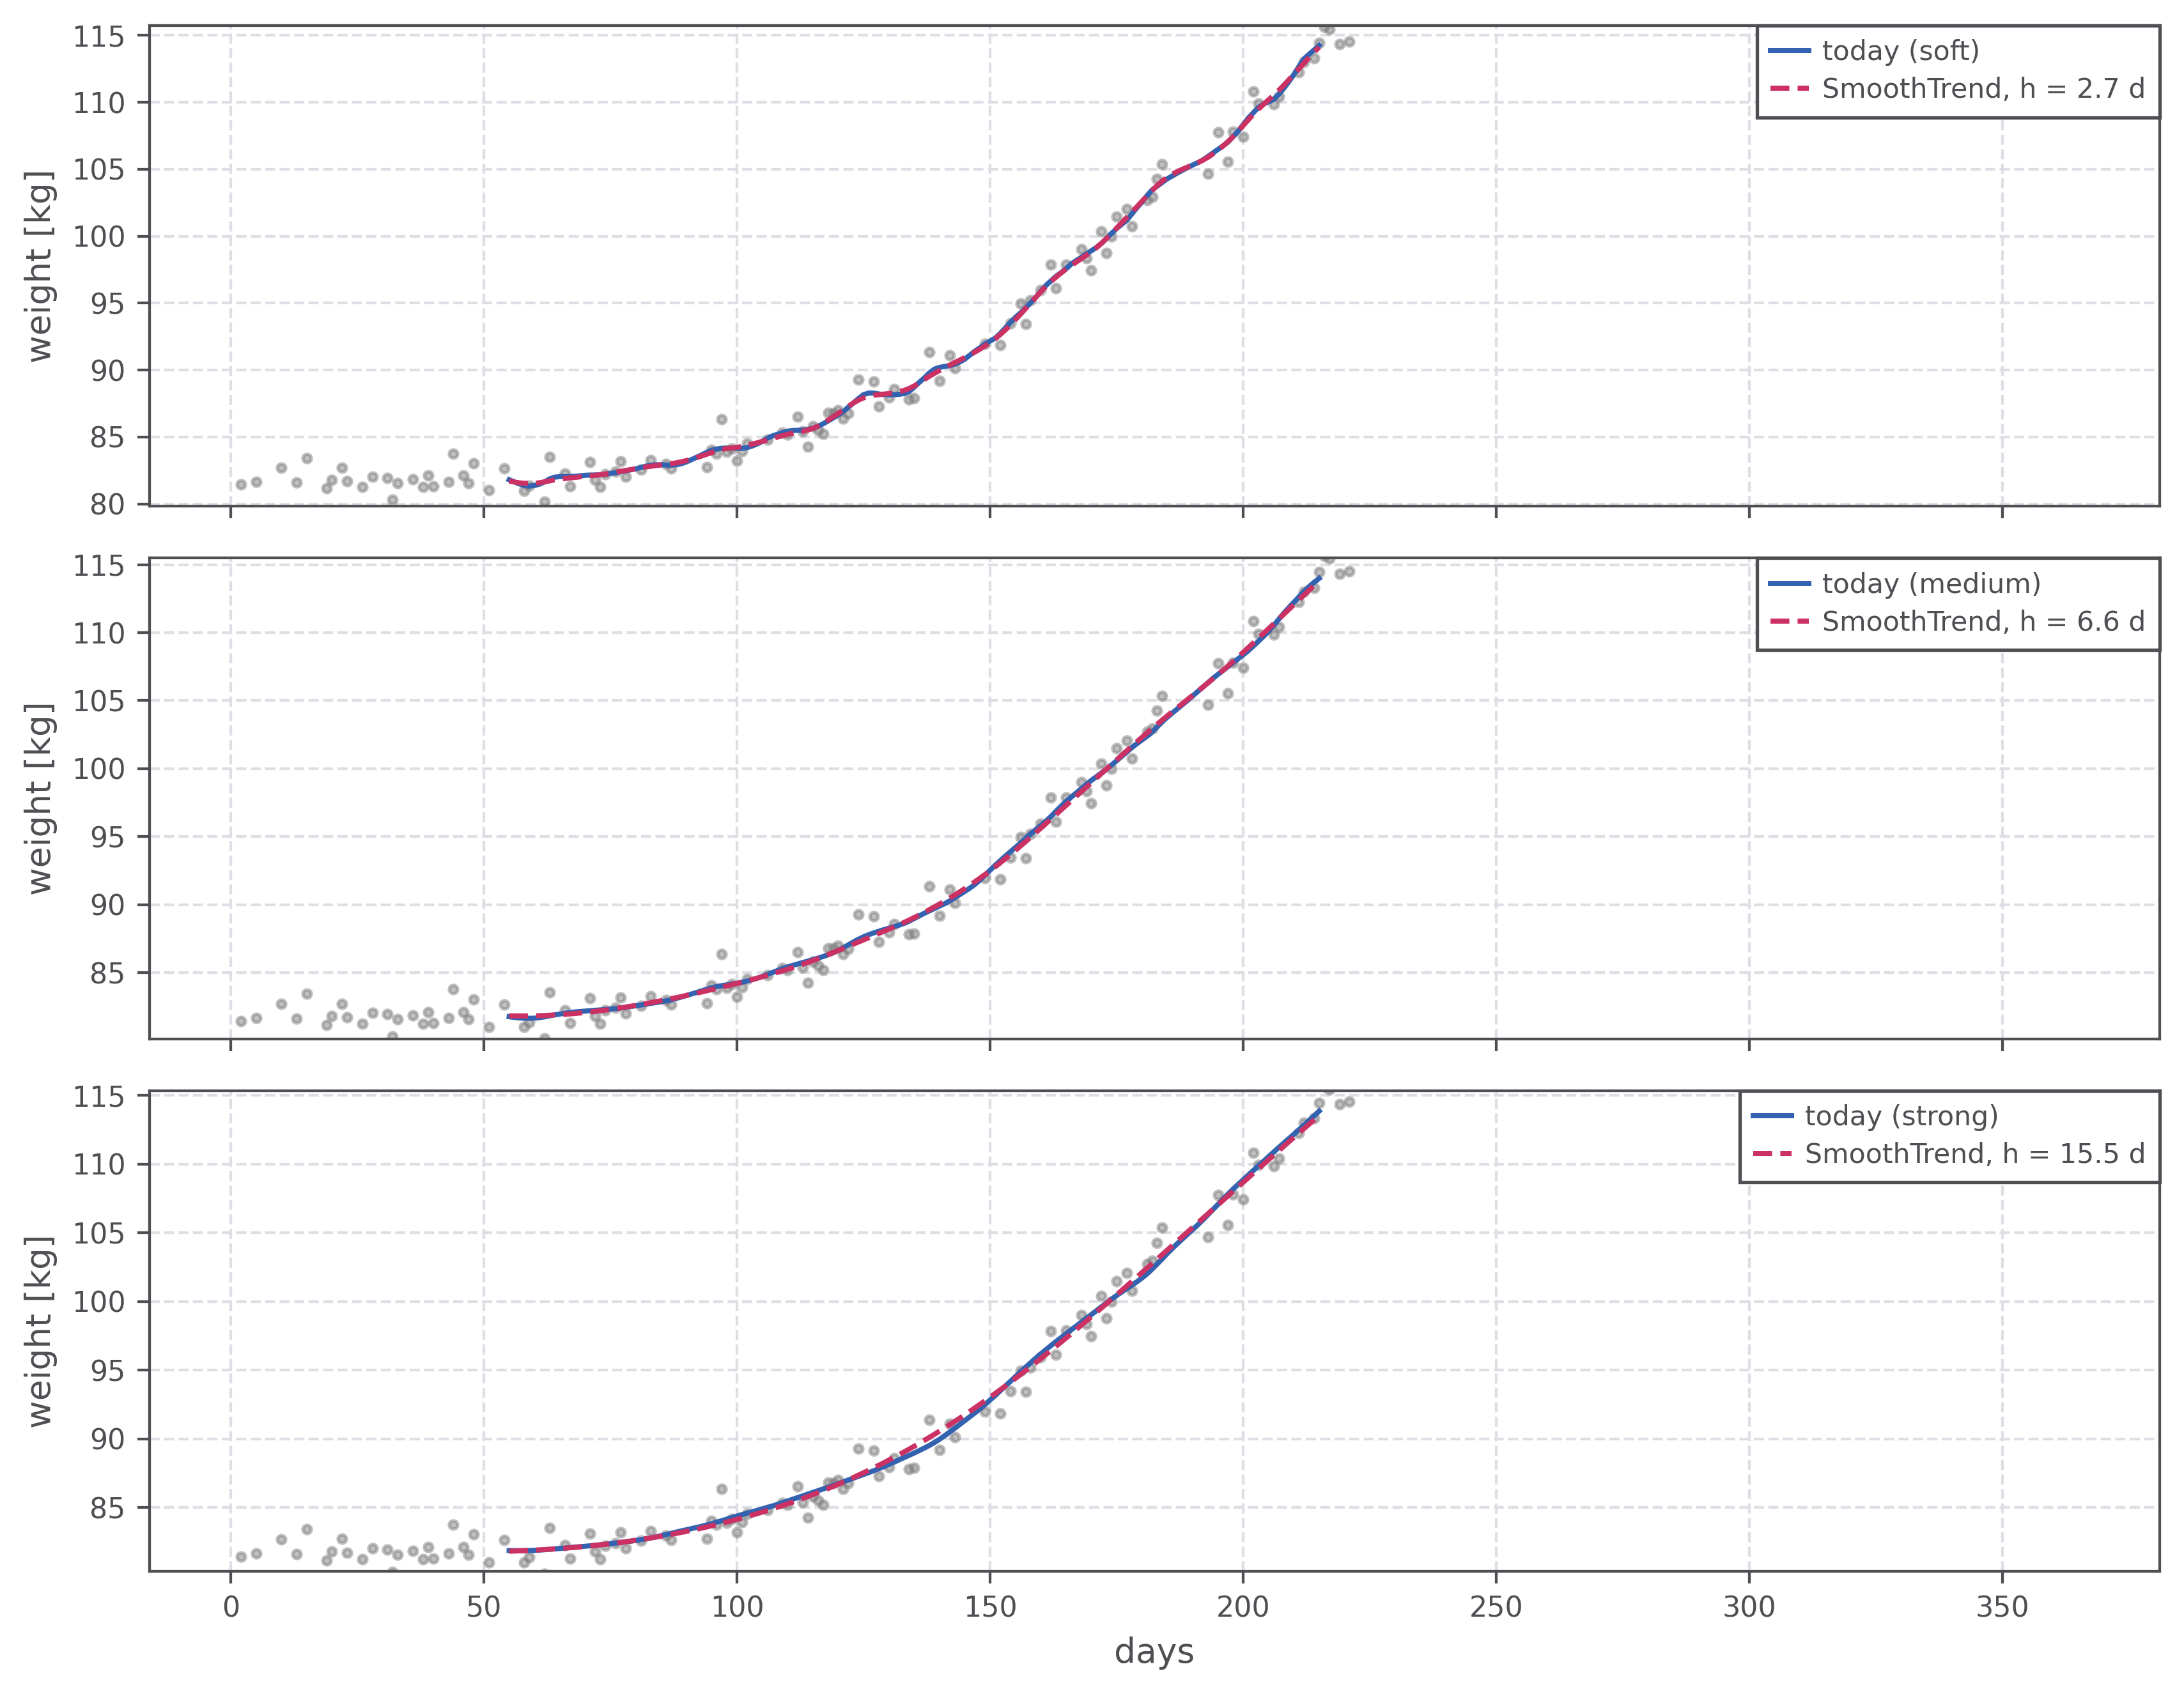

In [51]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
window = (grid >= grid[60]) & (grid <= grid[220])
for ax, (label, (best, target)) in zip(axes, matched.items(), strict=True):
    ax.scatter(times, weights, s=6, color="grey", alpha=0.5)
    ax.plot(grid[window], target[window], lw=1.5, label=f"today ({label})")
    ax.plot(
        grid[window],
        SmoothTrend(lam=best**-4.0, sigma_eps=sigma_hat, robust_c=None)
        .fit(times, weights)
        .predict(grid)[window],
        lw=1.5, ls="--", label=f"SmoothTrend, h = {best:.1f} d",
    )
    ax.set_ylim(np.min(target[window]) - 1.5, np.max(target[window]) + 1.5)
    ax.set_ylabel("weight [kg]")
    ax.legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("days")
plt.tight_layout()
plt.show()


---

# §8 — Is a weekly component worth adding? (follow-up, not this PR)

Body weight has a real weekly cycle. Neither the current pipeline nor
`SmoothTrend` models it; both absorb it into the noise, inflating
`sigma_eps`. Periodic components do have an exact `O(N)` state-space form
(Solin & Sarkka 2014), so this is reachable later — at the cost of a 4-state
model and generic matrix routines, which is exactly the sort of thing that
makes a Dart port harder.

Two measurements decide whether it is worth it: how large the weekday effect
actually is, and whether correcting for it improves out-of-sample forecasts.

The same cell also reads off the amplitudes the repo's own `GaussianProcess`
assigns to its weekly, monthly and annual kernels. The monthly one is hard
to defend a priori — there is no 30-day cycle in body weight except the
menstrual cycle, whose period is individual (24–35 days), varies within a
person, and is not phase-locked to the calendar. Rather than argue that, the
fitted amplitude can simply be reported.


In [52]:
times, weights = SERIES["synthetic_2y"]
model = SmoothTrend().fit(times, weights)
residual = weights - model.predict(times)
weekday = (times.astype(int) % 7)

print(f"{'weekday':>8}  {'n':>5}  {'mean residual [kg]':>19}  {'s.e.':>7}")
amplitudes = []
for day in range(7):
    mask = weekday == day
    mean = residual[mask].mean()
    sem = residual[mask].std(ddof=1) / np.sqrt(mask.sum())
    amplitudes.append(mean)
    print(f"{day:8d}  {mask.sum():5d}  {mean:19.3f}  {sem:7.3f}")

print(f"\nweekday peak-to-peak: {max(amplitudes) - min(amplitudes):.3f} kg")
print(f"estimated sigma_eps:  {model.sigma_eps_:.3f} kg")


 weekday      n   mean residual [kg]     s.e.
       0     56                0.098    0.112
       1     62                0.309    0.109
       2     67               -0.067    0.099
       3     66               -0.252    0.097
       4     59               -0.218    0.093
       5     61                0.017    0.083
       6     66                0.202    0.093

weekday peak-to-peak: 0.561 kg
estimated sigma_eps:  0.816 kg


In [53]:
class WeekdayAdjusted(Interpolator):
    # Crude stand-in for a proper periodic state-space component: fit the
    # weekday means on the training prefix only, then add them back.
    def fit(self, times_measured, weights_measured):
        self._base = SmoothTrend().fit(times_measured, weights_measured)
        residual = weights_measured - self._base.predict(times_measured)
        self._offset = np.zeros(7)
        for day in range(7):
            mask = (times_measured.astype(int) % 7) == day
            if mask.sum() >= 3:
                self._offset[day] = residual[mask].mean()
        return self

    def predict(self, times):
        times = np.asarray(times, float)
        return self._base.predict(times) + self._offset[times.astype(int) % 7]


adjusted = forward_chain(times, weights, lambda t, w: WeekdayAdjusted().fit(t, w))
plain_records = CHAINS["synthetic_2y"]["SmoothTrend"]

print(f"{'horizon':>8}  {'RMSE plain':>11}  {'RMSE + weekday':>15}  {'gain':>7}")
for horizon in (1, 3, 7):
    plain_rows = plain_records[plain_records[:, 0] == horizon]
    adjusted_rows = adjusted[adjusted[:, 0] == horizon]
    plain = np.sqrt(np.mean((plain_rows[:, 1] - plain_rows[:, 2]) ** 2))
    corrected = np.sqrt(np.mean((adjusted_rows[:, 1] - adjusted_rows[:, 2]) ** 2))
    print(
        f"{horizon:8d}  {plain:11.3f}  {corrected:15.3f}  "
        f"{(1 - corrected / plain) * 100:6.1f}%"
    )

tuned = tuned_gp("synthetic_2y", times, weights)
print("\nGaussianProcess fitted component amplitudes [kg]:")
for component in ("trend", "weekly", "monthly", "annual"):
    variance = getattr(tuned._gp, f"{component}_signal_variance")
    print(f"  {component:>8}: {np.sqrt(abs(variance)):.3f}")
print(f"  {'noise':>8}: {np.sqrt(abs(tuned._gp.noise_variance)):.3f}")


 horizon   RMSE plain   RMSE + weekday     gain
       1        0.894            0.872     2.5%
       3        0.944            0.928     1.7%
       7        1.053            1.042     1.1%

GaussianProcess fitted component amplitudes [kg]:
     trend: 12.136
    weekly: 0.224
   monthly: 0.224
    annual: 0.224
     noise: 0.817


---

# Summary

What this notebook set out to establish, and what it actually shows, should
be read off the tables above rather than from this list — but the intended
claims are:

1. **The optimizer objection dissolves.** The fit is a 40-point grid search
   over one scalar, agreeing with Brent's method to a fraction of a percent,
   and costing fewer flops than a single evaluation of the current
   algorithm. Fifteen lines of Dart, no packages.
2. **Forecasts are competitive**, and where they are not — short horizons
   especially — the tables say so.
3. **The uncertainty is calibrated**, which no algorithm in the repository
   could previously claim, and which is what issue #93 needs.
4. **The cost is linear**, and loop-against-loop — the comparison that
   predicts Dart — the margin is large.
5. **Outliers are discounted rather than smeared**, without the filter
   refusing to follow genuine changes.
6. **The current look is reproducible** by choosing `lam` per slider
   position, so nothing in the UI has to change.

Out of scope for the PR, and deliberately so: weekly seasonality, iterated
Student-t, exact diffuse initialisation, damped trend, and any change to
`Trale` itself. The PR is purely additive — if it does not convince, nothing
in the repository breaks.
